# Model Benchmark Investigation

This notebook complements `scripts/benchmark_models.py` with custom, thesis-oriented inspection workflows.

## A. Total Training Evaluation

### 1. Aggregate Metrics Comparison

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "src").exists() and (cand / "scripts").exists():
            return cand
    raise FileNotFoundError("Could not detect repo root (expected folders: src/, scripts/).")

REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from energy_trading.evaluation.gate_synced_analysis import (
    target_policy,
    gate_time_dplus1_filter,
    build_tail_metrics,
    aggregate_tail_metrics,
    compute_quantile_coverage,
    plot_tail_calibration,
    plot_quantile_coverage_bars,
)


from energy_trading.visualization.style import apply_geo_style, THESIS_PALETTE
from energy_trading.utils.run_context import resolve_model_run_dirs

apply_geo_style()

# -------------------------------
# Benchmark run configuration
# -------------------------------
MODEL_KEY_XGB = "xgboost"
MODEL_KEY_TFT = "tft"
MODEL_KEY_LINEAR = "linear"

MODEL_RUN_DIRS = resolve_model_run_dirs(
    repo_root=REPO_ROOT,
    models=(MODEL_KEY_XGB, MODEL_KEY_TFT, MODEL_KEY_LINEAR),
)
RUN_DIR_XGB = MODEL_RUN_DIRS[MODEL_KEY_XGB]
RUN_DIR_TFT = MODEL_RUN_DIRS[MODEL_KEY_TFT]
RUN_DIR_LINEAR = MODEL_RUN_DIRS[MODEL_KEY_LINEAR]

BENCHMARK_NAME = f"benchmark_{RUN_DIR_XGB.name}_{RUN_DIR_TFT.name}_{RUN_DIR_LINEAR.name}"
SPLIT = "test"
LEAD = 24
WINDOW_DAYS = 5
WEEK_HOURS = 24 * 7
WEEK_REFERENCE_PRED_COL = "pred_afrr_activation_price_neg"

BENCHMARK_DIR = REPO_ROOT / "artifacts" / "benchmarks" / BENCHMARK_NAME
SUMMARY_CSV = BENCHMARK_DIR / "benchmark_summary.csv"

print("Resolved run dirs:")
print(f" - xgboost: {RUN_DIR_XGB.name}")
print(f" - tft: {RUN_DIR_TFT.name}")
print(f" - linear: {RUN_DIR_LINEAR.name}")

TRUTH_COL_BY_PRED = {
    "pred_da_price": "target_da_price",
    "pred_afrr_activation_price_pos": "target_afrr_activation_price_vwap_pos",
    "pred_afrr_activation_price_neg": "target_afrr_activation_price_vwap_neg",
    "pred_afrr_capacity_price_pos": "target_afrr_capacity_price_pos",
    "pred_afrr_capacity_price_neg": "target_afrr_capacity_price_neg",
    "pred_afrr_activation_rate_pos": "target_afrr_activation_rate_pos",
    "pred_afrr_activation_rate_neg": "target_afrr_activation_rate_neg",
}

# In-notebook caches to avoid repeated heavy parquet reads/processing.
LONG_DF_CACHE: dict[tuple[str, str, str, str], pd.DataFrame] = {}
LONG_PATH_CACHE: dict[tuple[str, str, str, str], Path] = {}
TRUTH_SERIES_CACHE: dict[str, pd.Series] = {}

def load_manifest(run_dir: Path) -> dict:
    mp = run_dir / "manifest.json"
    if not mp.exists():
        raise FileNotFoundError(f"Missing manifest: {mp}")
    return json.loads(mp.read_text())

def resolve_truth_path(run_dir: Path, manifest: dict) -> Path:
    sm = run_dir / "summary_metrics.json"
    if sm.exists():
        payload = json.loads(sm.read_text())
        gp = payload.get("ground_truth_path", "")
        if gp and Path(gp).exists():
            return Path(gp)
    mp = manifest.get("ground_truth", {}).get("default_path", "")
    if mp and Path(mp).exists():
        return Path(mp)
    return REPO_ROOT / "data" / "features" / "all_data_features.parquet"

def load_truth_df(path: Path) -> pd.DataFrame:
    truth = pd.read_parquet(path)
    truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True, errors="coerce")
    missing = [c for c in TRUTH_COL_BY_PRED.values() if c not in truth.columns]
    if missing:
        raise KeyError(f"Missing truth columns in {path}: {sorted(set(missing))}")
    return truth

def _matches_model_key(path: Path, model_key: str) -> bool:
    if not model_key:
        return True
    mk = model_key.strip().lower()
    name = path.name.lower()
    if mk in {"xgb", "xgboost"}:
        return "xgboost" in name
    if mk == "linear":
        return "linear" in name
    if mk == "tft":
        # TFT exports in this repo are often unlabeled in filename
        # (e.g., da_target_da_price_...); exclude explicit non-TFT families.
        return ("xgboost" not in name) and ("linear" not in name)
    return mk in name

def _discover_long_prediction_file(run_dir: Path, split: str, pred_col: str, model_key: str) -> Path:
    pred_dir = run_dir / "predictions"
    if not pred_dir.exists():
        raise FileNotFoundError(f"Missing predictions dir: {pred_dir}")

    pats = [
        f"*{split}*{pred_col}*long*.parquet",
        f"*{pred_col}*long*{split}*.parquet",
        f"*{pred_col}*{split}*long*.parquet",
    ]
    candidates: list[Path] = []
    for pat in pats:
        candidates.extend(sorted(pred_dir.glob(pat)))

    if model_key:
        candidates = [c for c in candidates if _matches_model_key(c, model_key)]

    if not candidates:
        raise FileNotFoundError(
            f"No long prediction file for pred_col={pred_col}, split={split}, model_key={model_key} in {pred_dir}"
        )
    return candidates[0]

def load_long_df(run_dir: Path, pred_col: str, model_key: str) -> pd.DataFrame:
    key = (str(run_dir.resolve()), str(pred_col), str(model_key), str(SPLIT))
    if key in LONG_DF_CACHE:
        return LONG_DF_CACHE[key].copy()

    if key in LONG_PATH_CACHE:
        p = LONG_PATH_CACHE[key]
    else:
        p = _discover_long_prediction_file(run_dir, SPLIT, pred_col, model_key)
        LONG_PATH_CACHE[key] = p

    df = pd.read_parquet(p)
    ts_col = next((c for c in ["target_time_utc", "timestamp_utc", "timestamp"] if c in df.columns), None)
    if ts_col is None:
        raise KeyError(f"Missing timestamp col in {p}. Found: {list(df.columns)}")

    # Keep only columns used downstream to reduce memory pressure.
    keep = [c for c in [ts_col, 'snapshot_time_utc', 'lead_time_h', 'predicted_value', 'p10', 'p50', 'p90'] if c in df.columns]
    df = df[keep].copy()

    df["target_time_utc"] = pd.to_datetime(df[ts_col], utc=True, errors="coerce")
    if "snapshot_time_utc" in df.columns:
        df["snapshot_time_utc"] = pd.to_datetime(df["snapshot_time_utc"], utc=True, errors="coerce")
    if "lead_time_h" in df.columns:
        df["lead_time_h"] = pd.to_numeric(df["lead_time_h"], errors="coerce")
    else:
        df["lead_time_h"] = 1
    if "p50" not in df.columns and "predicted_value" in df.columns:
        df["p50"] = pd.to_numeric(df["predicted_value"], errors="coerce")

    LONG_DF_CACHE[key] = df
    return df.copy()

def _model_has_pred_col(run_dir: Path, pred_col: str, model_key: str) -> bool:
    try:
        _discover_long_prediction_file(run_dir, SPLIT, pred_col, model_key)
        return True
    except Exception:
        return False

def compute_metrics_by_lead_for_model(pred_col: str, run_dir: Path, model_key: str) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]
    long_df = load_long_df(run_dir, pred_col, model_key)
    pred_col_name = "p50" if "p50" in long_df.columns else "predicted_value"
    d = long_df[["target_time_utc", "lead_time_h", pred_col_name]].copy().rename(columns={pred_col_name: "y_pred"})

    t = truth_df[["timestamp_utc", truth_col]].copy().rename(columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"})
    d = d.merge(t, on="target_time_utc", how="left")

    if truth_col in TRUTH_SERIES_CACHE:
        truth_by_ts = TRUTH_SERIES_CACHE[truth_col]
    else:
        truth_by_ts = t.dropna(subset=["target_time_utc"]).set_index("target_time_utc")["y_true"].copy()
        TRUTH_SERIES_CACHE[truth_col] = truth_by_ts
    d["y_naive_24h"] = truth_by_ts.reindex(d["target_time_utc"] - pd.Timedelta(hours=24)).to_numpy()

    out = []
    for lead, g in d.groupby("lead_time_h", dropna=True):
        yt = pd.to_numeric(g["y_true"], errors="coerce").to_numpy(dtype=float)
        yp = pd.to_numeric(g["y_pred"], errors="coerce").to_numpy(dtype=float)
        yn = pd.to_numeric(g["y_naive_24h"], errors="coerce").to_numpy(dtype=float)
        m = np.isfinite(yt) & np.isfinite(yp)
        mn = m & np.isfinite(yn)
        if not np.any(m):
            continue
        mae = float(np.mean(np.abs(yt[m] - yp[m])))
        skill = np.nan
        if np.any(mn):
            mae_naive = float(np.mean(np.abs(yt[mn] - yn[mn])))
            if np.isfinite(mae_naive) and mae_naive != 0:
                skill = float(1.0 - mae / mae_naive)
        out.append({"lead_time_h": float(lead), "mae": mae, "skill_score_mae": skill})
    return pd.DataFrame(out).sort_values("lead_time_h").reset_index(drop=True)

mx = load_manifest(RUN_DIR_XGB)
truth_path = resolve_truth_path(RUN_DIR_XGB, mx)
truth_df = load_truth_df(truth_path)

COMMON_PRED_COLS = [
    p for p in sorted(TRUTH_COL_BY_PRED)
    if _model_has_pred_col(RUN_DIR_XGB, p, MODEL_KEY_XGB)
    and _model_has_pred_col(RUN_DIR_TFT, p, MODEL_KEY_TFT)
    and _model_has_pred_col(RUN_DIR_LINEAR, p, MODEL_KEY_LINEAR)
]
if not COMMON_PRED_COLS:
    raise ValueError("No common prediction columns found for configured model keys in the selected run dirs.")

summary_df = pd.read_csv(SUMMARY_CSV) if SUMMARY_CSV.exists() else pd.DataFrame()
summary_df

def load_merged_for_target(pred_col: str, lead: int = 1) -> pd.DataFrame:
    """Backward-compatible helper used by Section 4 deep-dive.

    Returns columns: target_time_utc, y_true, xgb_p50, tft_p50, lin_p50.
    """
    if pred_col not in TRUTH_COL_BY_PRED:
        raise KeyError(f"Unknown pred_col={pred_col}. Available: {sorted(TRUTH_COL_BY_PRED)}")

    truth_col = TRUTH_COL_BY_PRED[pred_col]
    base = truth_df[["timestamp_utc", truth_col]].copy().rename(
        columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"}
    )
    base["target_time_utc"] = pd.to_datetime(base["target_time_utc"], utc=True, errors="coerce")

    def _model_part(run_dir: Path, model_key: str, out_col: str) -> pd.DataFrame:
        m = load_long_df(run_dir, pred_col, model_key).copy()
        if "lead_time_h" in m.columns:
            m = m.loc[pd.to_numeric(m["lead_time_h"], errors="coerce") == float(lead)].copy()
        pred_col_name = "p50" if "p50" in m.columns else "predicted_value"
        if pred_col_name not in m.columns:
            raise KeyError(f"Missing p50/predicted_value for {pred_col} in {run_dir}")
        m = m[["target_time_utc", pred_col_name]].copy().rename(columns={pred_col_name: out_col})
        m["target_time_utc"] = pd.to_datetime(m["target_time_utc"], utc=True, errors="coerce")
        m[out_col] = pd.to_numeric(m[out_col], errors="coerce")
        m = m.sort_values("target_time_utc").drop_duplicates(subset=["target_time_utc"], keep="last")
        return m

    xgb = _model_part(RUN_DIR_XGB, MODEL_KEY_XGB, "xgb_p50")
    tft = _model_part(RUN_DIR_TFT, MODEL_KEY_TFT, "tft_p50")
    lin = _model_part(RUN_DIR_LINEAR, MODEL_KEY_LINEAR, "lin_p50")

    merged = base.merge(xgb, on="target_time_utc", how="inner")
    merged = merged.merge(tft, on="target_time_utc", how="inner")
    merged = merged.merge(lin, on="target_time_utc", how="inner")
    merged = merged.sort_values("target_time_utc").reset_index(drop=True)

    # Ensure numeric payload for downstream MAE plotting.
    for c in ["y_true", "xgb_p50", "tft_p50", "lin_p50"]:
        merged[c] = pd.to_numeric(merged[c], errors="coerce")
    return merged


def _week_slice_by_start(df: pd.DataFrame, start_utc: str | pd.Timestamp, hours: int = 24 * 7) -> pd.DataFrame:
    """Backward-compatible helper for section 4 weekly windows."""
    out = df.copy()
    out["target_time_utc"] = pd.to_datetime(out["target_time_utc"], utc=True, errors="coerce")
    start = pd.to_datetime(start_utc, utc=True, errors="coerce")
    if pd.isna(start):
        return out.iloc[0:0].copy()
    end = start + pd.Timedelta(hours=int(hours))
    return out[(out["target_time_utc"] >= start) & (out["target_time_utc"] < end)].copy().reset_index(drop=True)


# Backward-compatible defaults for Section 4 deep-dive windows.
def _infer_default_week_starts_from_truth(
    *,
    truth_col: str = "target_afrr_activation_price_vwap_neg",
    hours: int = 24 * 7,
) -> tuple[pd.Timestamp, pd.Timestamp]:
    tdf = truth_df[["timestamp_utc", truth_col]].copy() if truth_col in truth_df.columns else truth_df[["timestamp_utc"]].copy()
    tdf["timestamp_utc"] = pd.to_datetime(tdf["timestamp_utc"], utc=True, errors="coerce")
    if truth_col in tdf.columns:
        tdf["y"] = pd.to_numeric(tdf[truth_col], errors="coerce")
    else:
        tdf["y"] = np.nan
    tdf = tdf.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
    if tdf.empty:
        now = pd.Timestamp.utcnow().tz_localize("UTC")
        base = now.floor("D")
        return (base - pd.Timedelta(days=14), base - pd.Timedelta(days=7))

    # Typical week: latest full week available.
    last_ts = tdf["timestamp_utc"].max()
    typical_start = (last_ts - pd.Timedelta(hours=hours)).floor("D")

    # High-volatility week: rolling std peak window.
    if tdf["y"].notna().sum() >= max(24, hours // 2):
        roll = tdf["y"].rolling(window=hours, min_periods=max(24, hours // 2)).std()
        if roll.notna().any():
            end_idx = int(roll.idxmax())
            high_start = tdf.loc[max(0, end_idx - hours + 1), "timestamp_utc"].floor("D")
        else:
            high_start = typical_start - pd.Timedelta(days=7)
    else:
        high_start = typical_start - pd.Timedelta(days=7)

    if high_start >= typical_start:
        high_start = typical_start - pd.Timedelta(days=7)
    return (pd.to_datetime(high_start, utc=True), pd.to_datetime(typical_start, utc=True))


if "HIGH_WEEK_START_UTC" not in globals() or "TYPICAL_WEEK_START_UTC" not in globals():
    _hws, _tws = _infer_default_week_starts_from_truth()
    HIGH_WEEK_START_UTC = _hws
    TYPICAL_WEEK_START_UTC = _tws


KeyError: 'linear'

### 2. Horizon Degradation (All Targets)

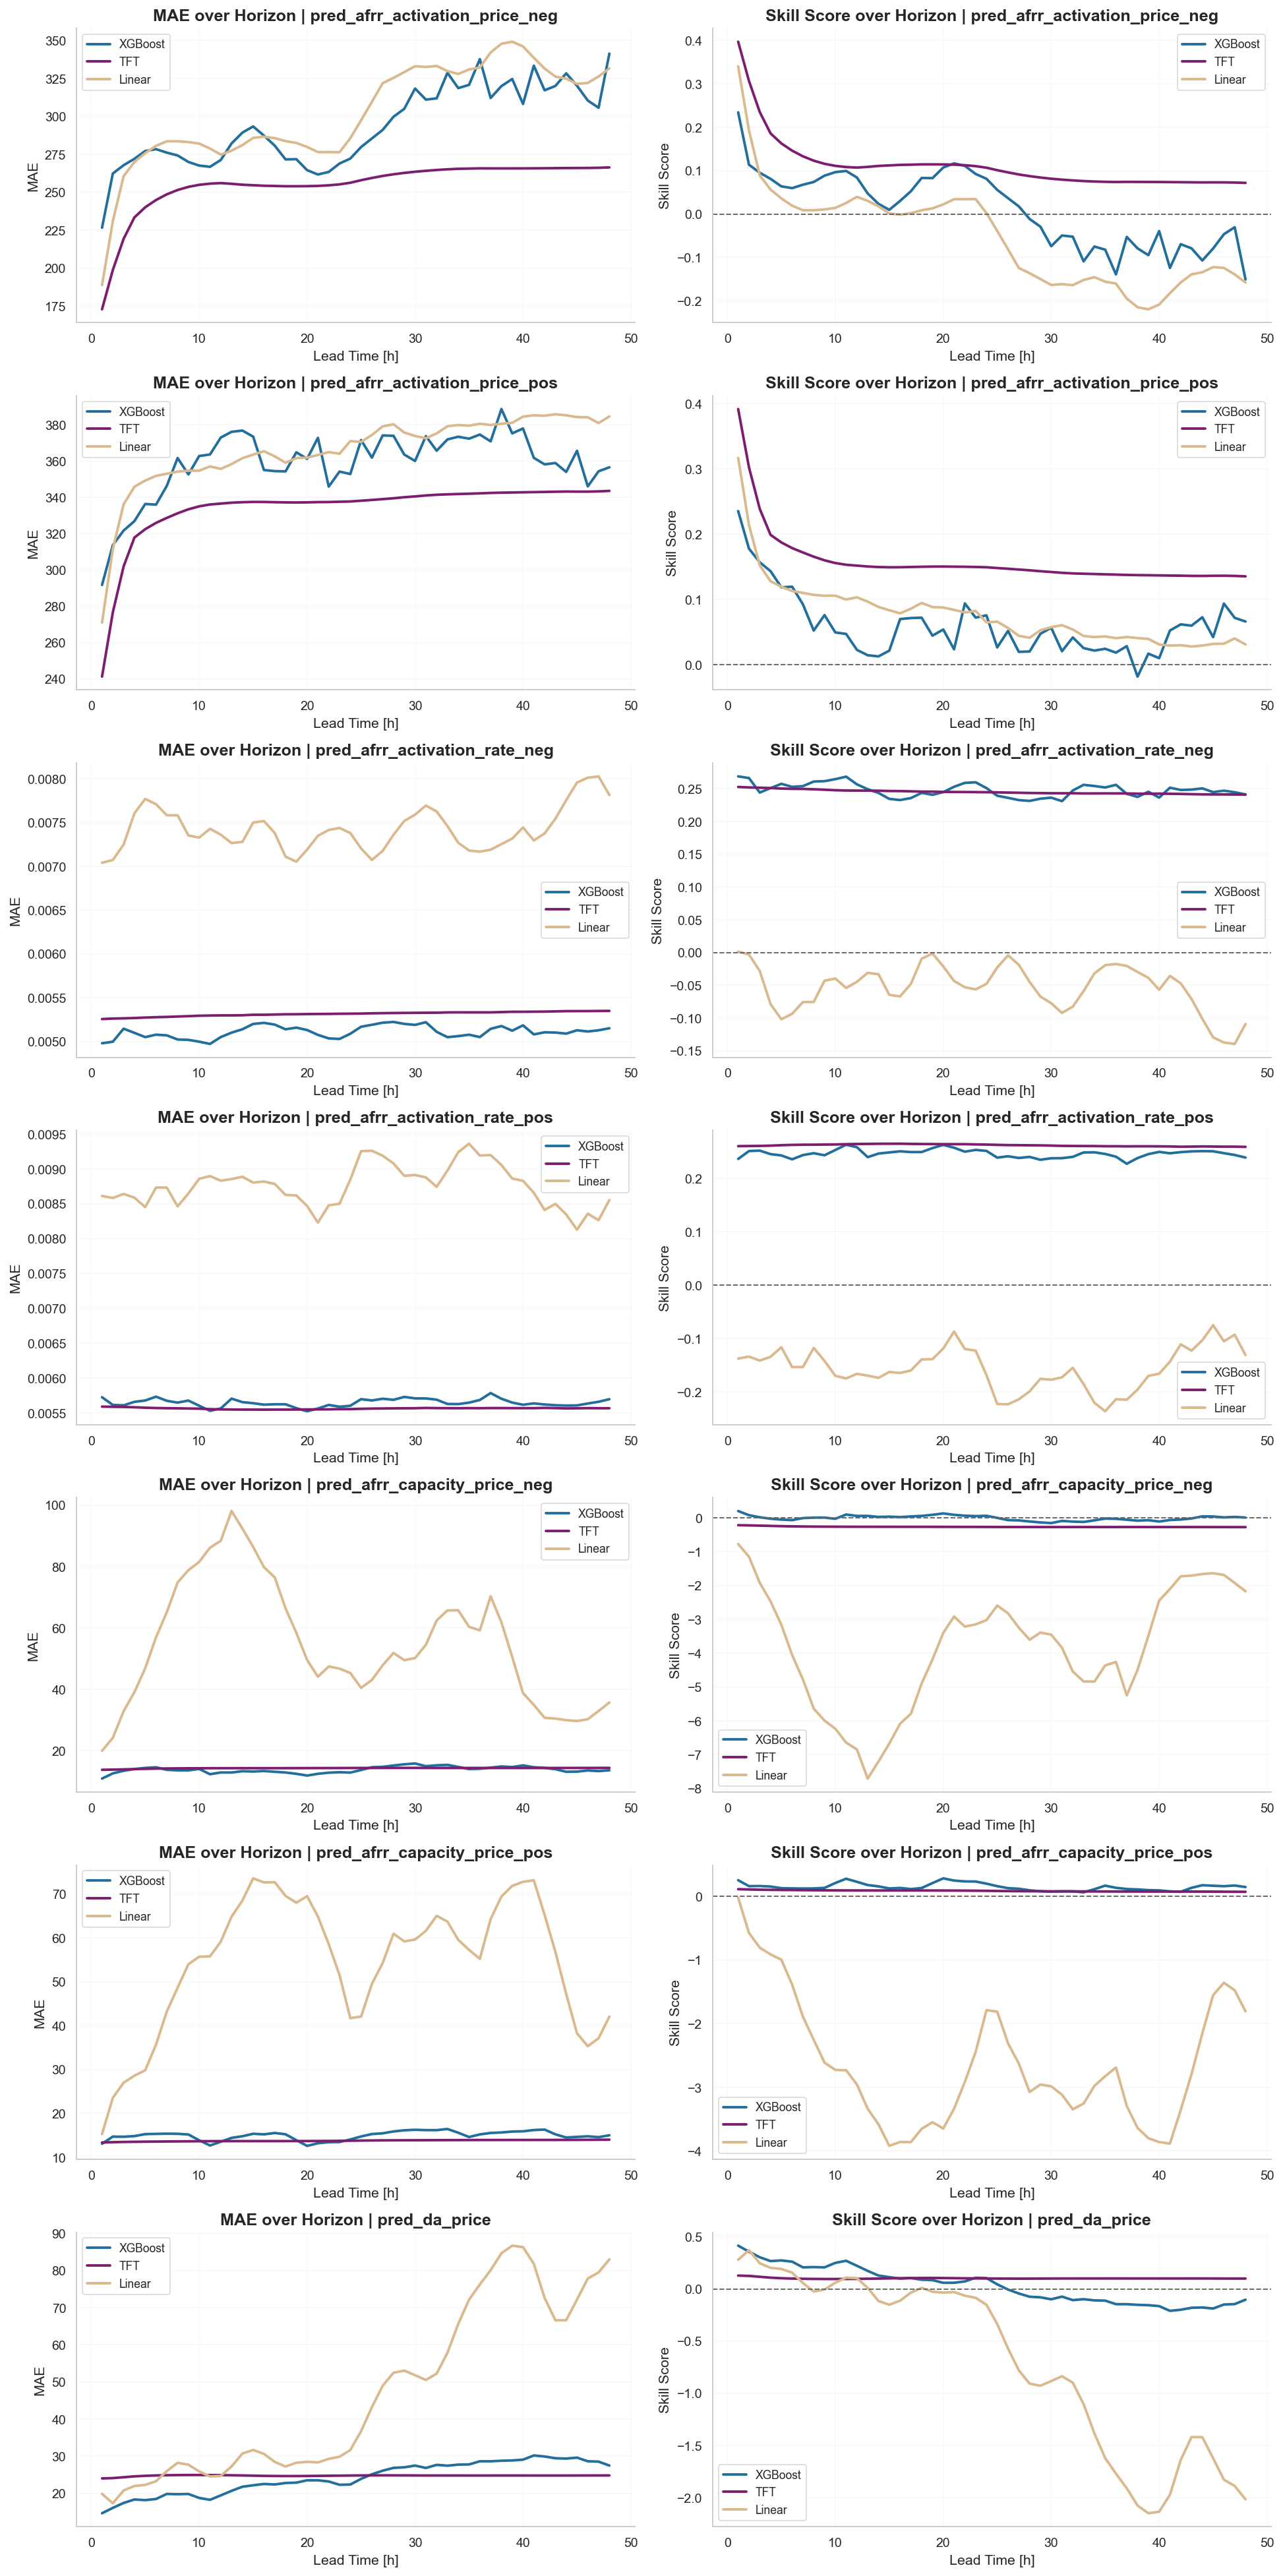

In [ ]:
import math

def _plot_horizon_series(ax, df: pd.DataFrame, x_col: str, y_col: str, *, label: str, color: str, linewidth: float = 2.0):
    x = pd.to_numeric(df[x_col], errors="coerce")
    y = pd.to_numeric(df[y_col], errors="coerce")
    m = x.notna() & y.notna()
    xs = x[m].to_numpy()
    ys = y[m].to_numpy()
    if len(xs) == 0:
        return
    if len(xs) == 1:
        # Linear baseline often has only lead=1; show explicit marker so it is visible.
        ax.plot(xs, ys, label=label, color=color, linewidth=linewidth, marker="o", markersize=6)
    else:
        ax.plot(xs, ys, label=label, color=color, linewidth=linewidth)

fig, axes = plt.subplots(len(COMMON_PRED_COLS), 2, figsize=(14, 4 * len(COMMON_PRED_COLS)), squeeze=False)

for r, pred_col in enumerate(COMMON_PRED_COLS):
    xgb_lead = compute_metrics_by_lead_for_model(pred_col, RUN_DIR_XGB, MODEL_KEY_XGB)
    tft_lead = compute_metrics_by_lead_for_model(pred_col, RUN_DIR_TFT, MODEL_KEY_TFT)
    lin_lead = compute_metrics_by_lead_for_model(pred_col, RUN_DIR_LINEAR, MODEL_KEY_LINEAR)

    if xgb_lead.empty or tft_lead.empty or lin_lead.empty:
        axes[r, 0].text(0.5, 0.5, f"missing lead metrics for {pred_col}", ha="center")
        axes[r, 1].text(0.5, 0.5, f"missing lead metrics for {pred_col}", ha="center")
        continue

    ax0 = axes[r, 0]
    _plot_horizon_series(ax0, xgb_lead, "lead_time_h", "mae", label="XGBoost", color=THESIS_PALETTE["primary"])
    _plot_horizon_series(ax0, tft_lead, "lead_time_h", "mae", label="TFT", color=THESIS_PALETTE["tertiary"])
    _plot_horizon_series(ax0, lin_lead, "lead_time_h", "mae", label="Linear", color=THESIS_PALETTE["secondary"])
    ax0.set_title(f"MAE over Horizon | {pred_col}")
    ax0.set_xlabel("Lead Time [h]")
    ax0.set_ylabel("MAE")
    ax0.legend()

    ax1 = axes[r, 1]
    if "skill_score_mae" in xgb_lead.columns and "skill_score_mae" in tft_lead.columns and "skill_score_mae" in lin_lead.columns:
        _plot_horizon_series(ax1, xgb_lead, "lead_time_h", "skill_score_mae", label="XGBoost", color=THESIS_PALETTE["primary"])
        _plot_horizon_series(ax1, tft_lead, "lead_time_h", "skill_score_mae", label="TFT", color=THESIS_PALETTE["tertiary"])
        _plot_horizon_series(ax1, lin_lead, "lead_time_h", "skill_score_mae", label="Linear", color=THESIS_PALETTE["secondary"])
        ax1.axhline(0.0, color="#666", linestyle="--", linewidth=1)
    else:
        ax1.text(0.5, 0.5, "skill_score_mae missing", ha="center")
    ax1.set_title(f"Skill Score over Horizon | {pred_col}")
    ax1.set_xlabel("Lead Time [h]")
    ax1.set_ylabel("Skill Score")
    ax1.legend()

plt.tight_layout()

### 3. Weekly Truth vs Predictions (Mon-Sun, All Targets)

### 4. Event Window Deep Dive (Selected Target, Mon-Sun)

[WARN] No rows for pred_afrr_activation_price_neg | High-Volatility | lead=24


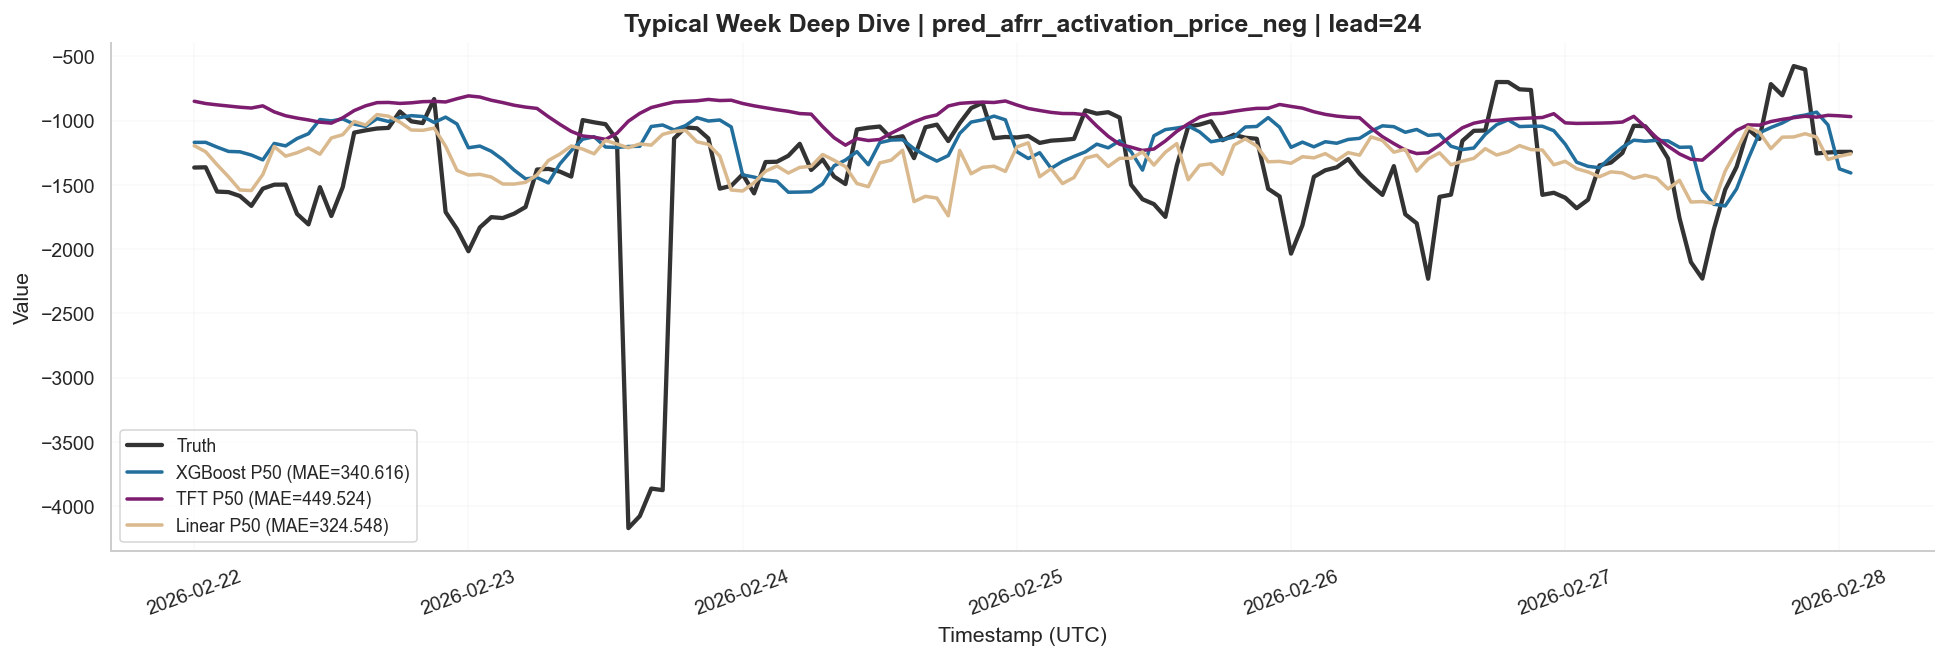

[WARN] No rows for pred_afrr_activation_price_pos | High-Volatility | lead=24


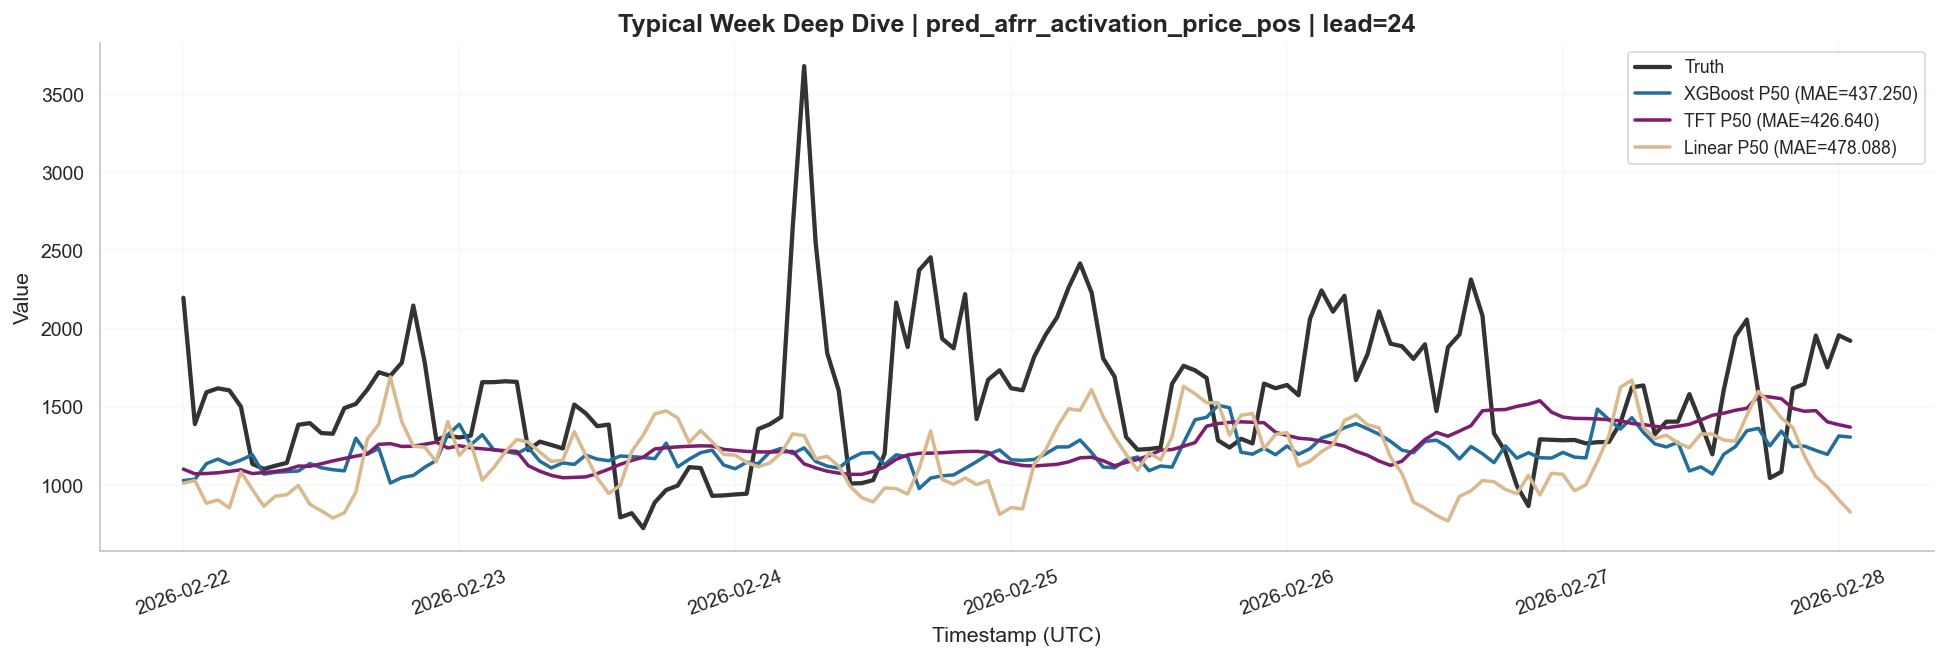

[WARN] No rows for pred_afrr_activation_rate_neg | High-Volatility | lead=24


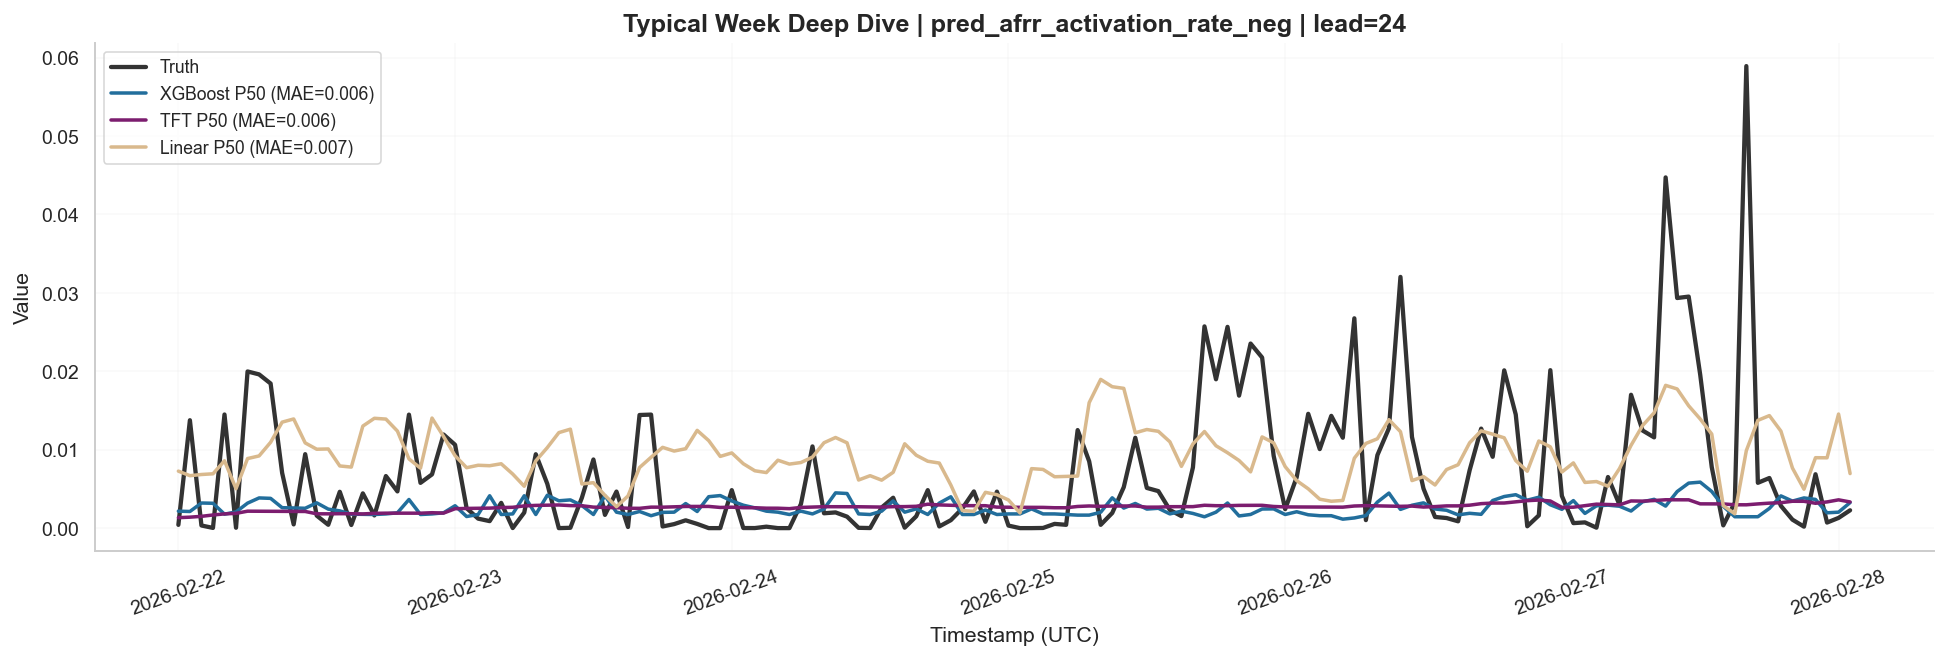

[WARN] No rows for pred_afrr_activation_rate_pos | High-Volatility | lead=24


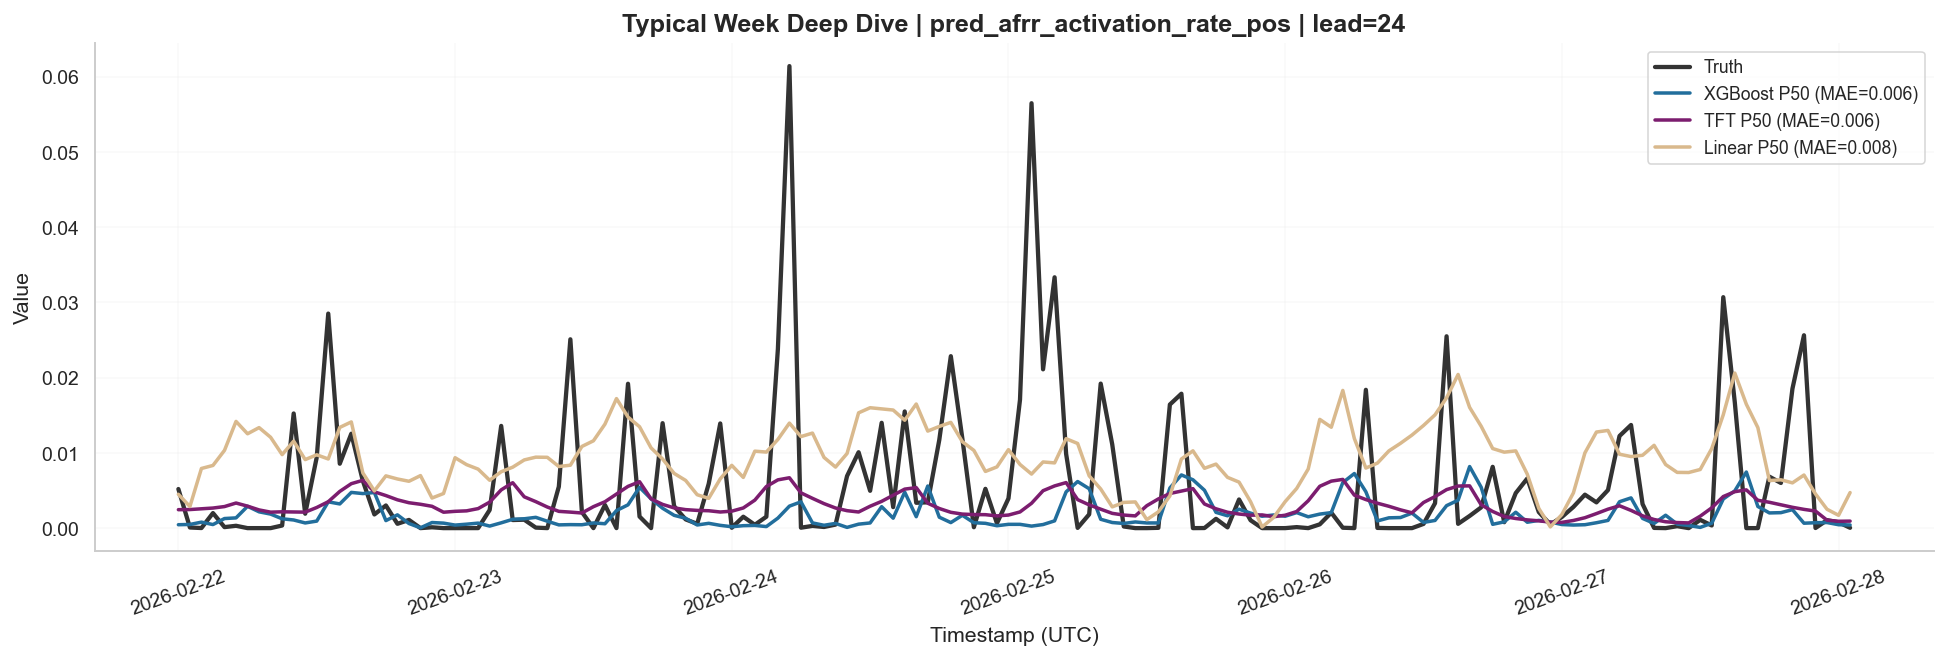

[WARN] No rows for pred_afrr_capacity_price_neg | High-Volatility | lead=24


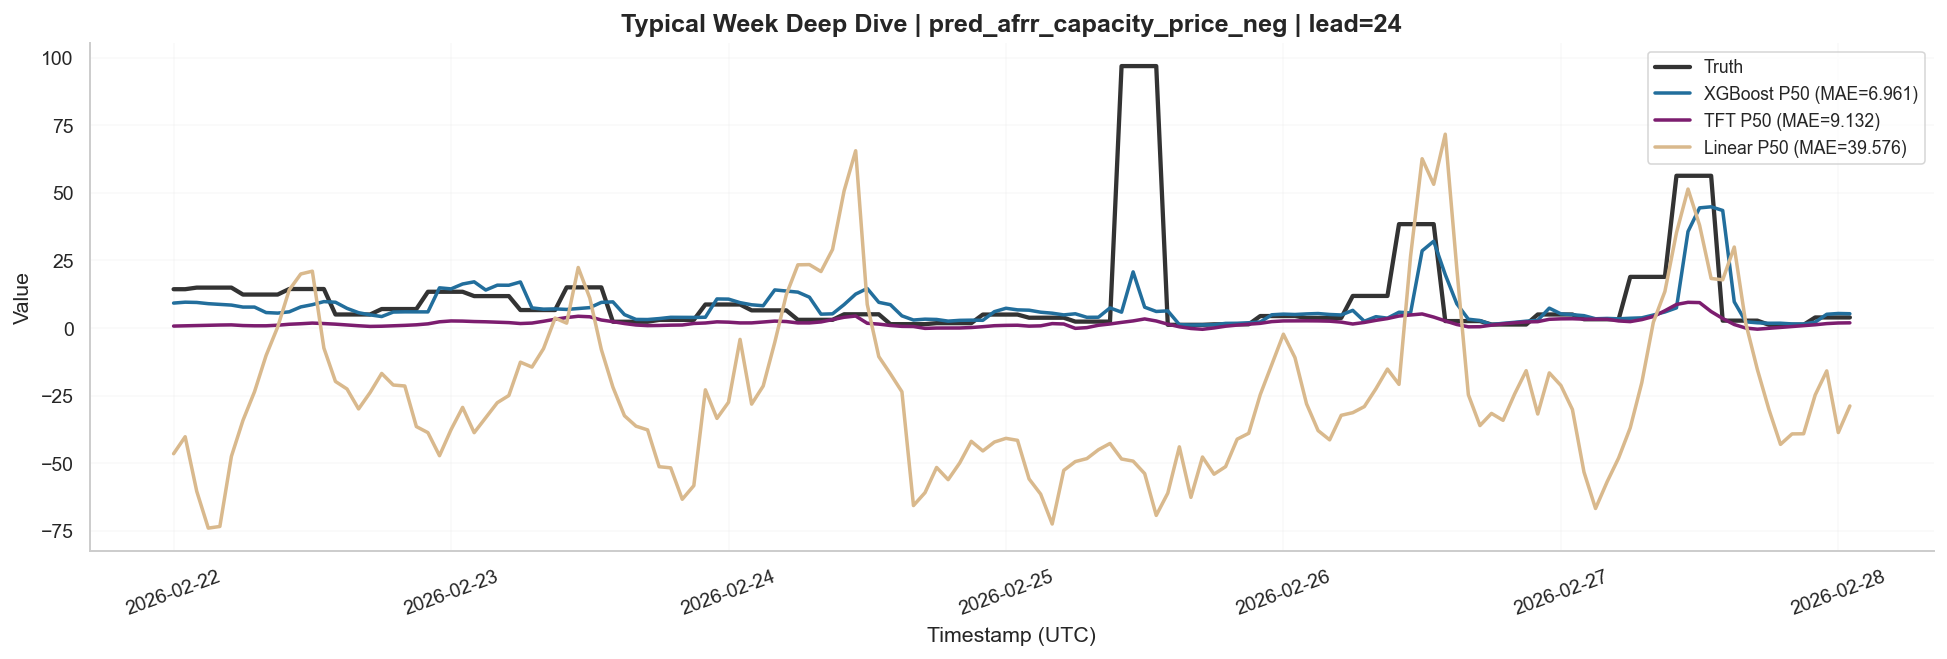

[WARN] No rows for pred_afrr_capacity_price_pos | High-Volatility | lead=24


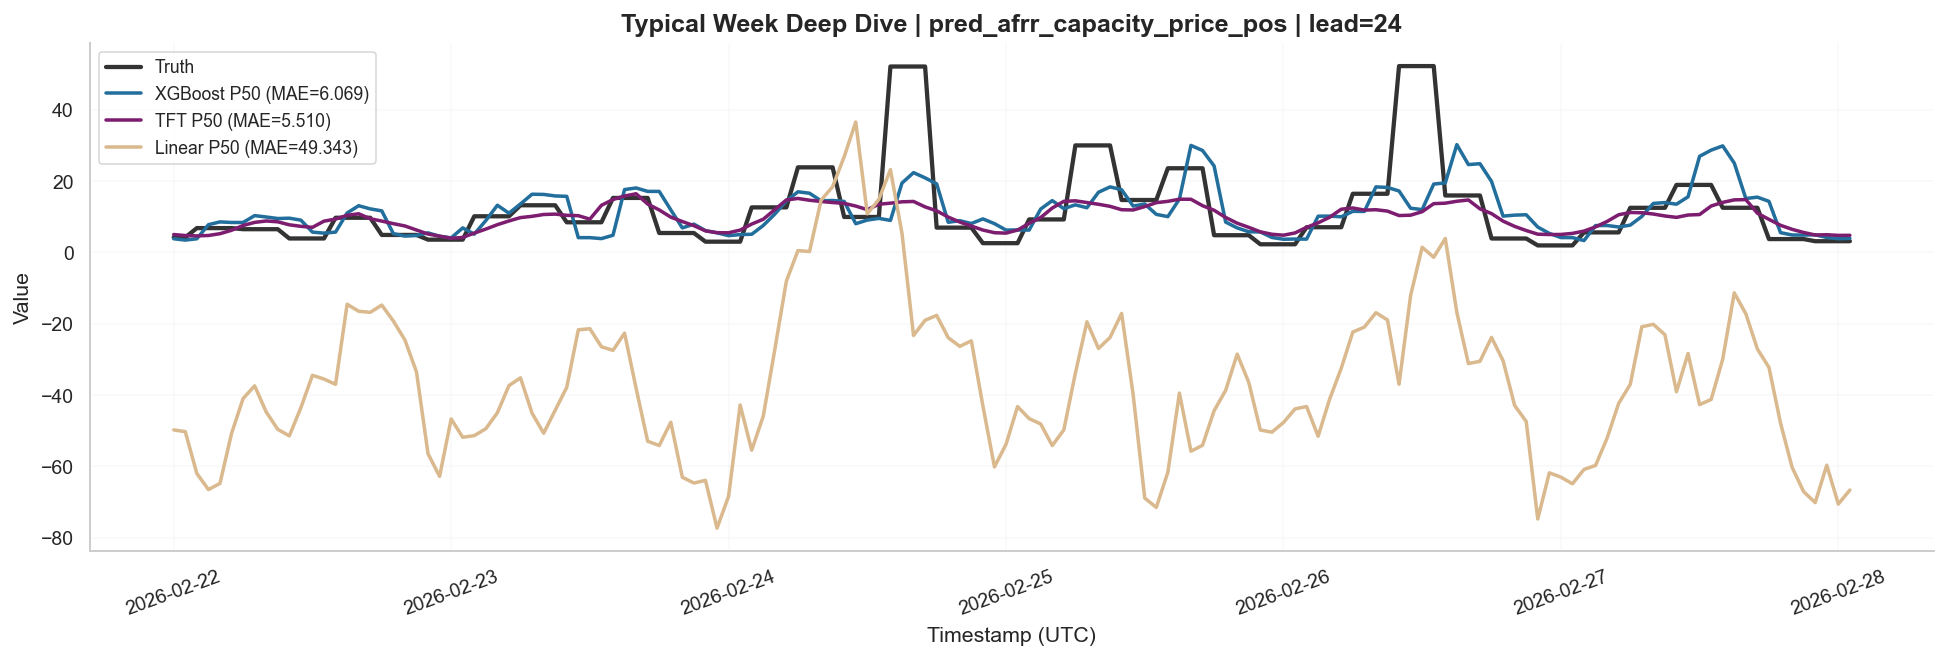

[WARN] No rows for pred_da_price | High-Volatility | lead=24


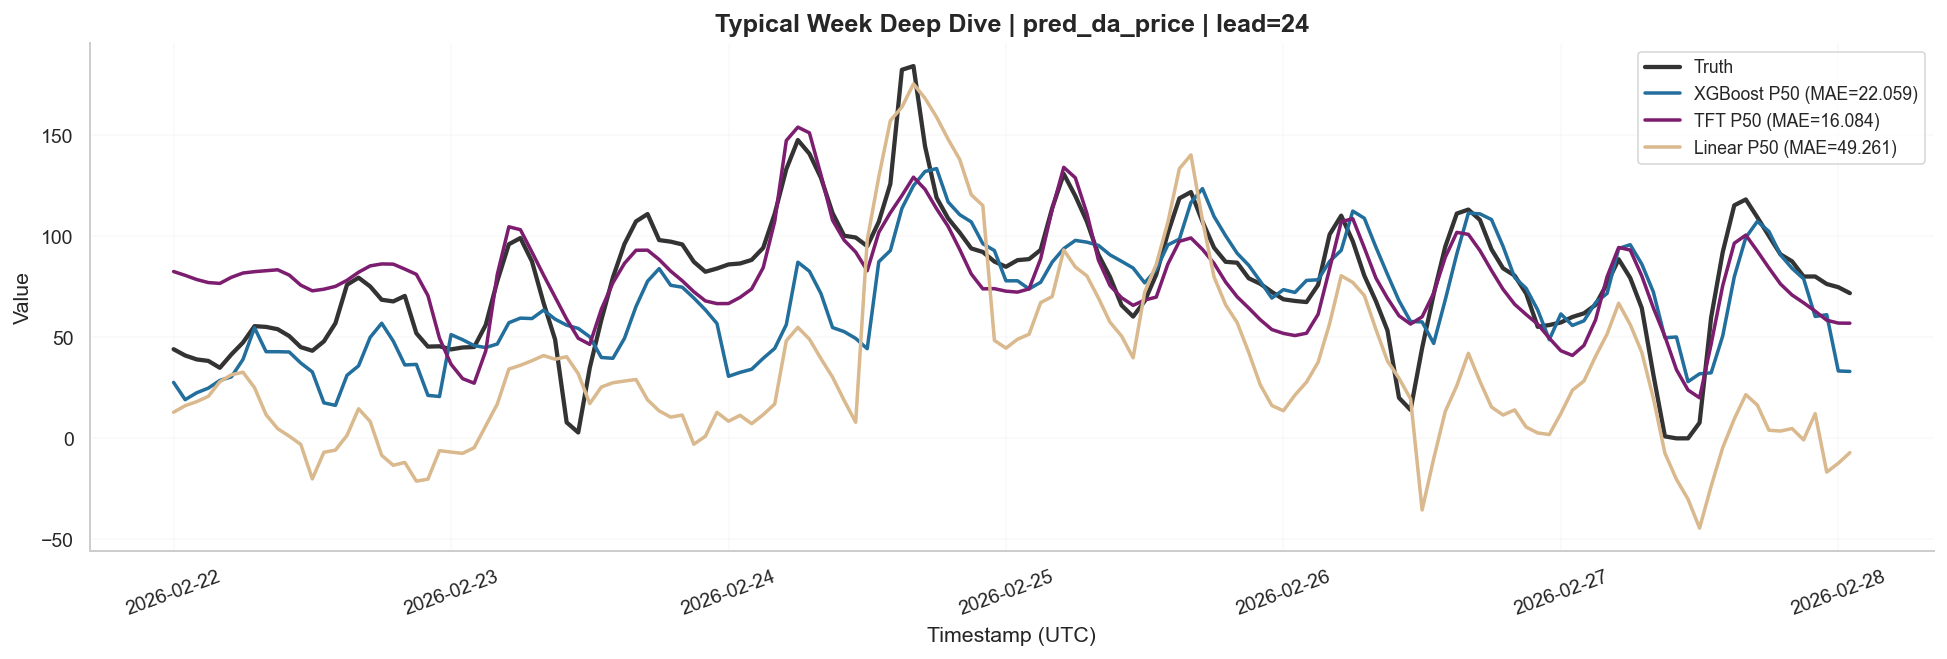

In [ ]:
# Event-window deep-dive for all targets (uses SAME global weeks as section 3)
EVENT_WINDOW_TARGETS = list(COMMON_PRED_COLS)

for selected_pred_col in EVENT_WINDOW_TARGETS:
    merged = load_merged_for_target(selected_pred_col, lead=LEAD)
    high_week = _week_slice_by_start(merged, HIGH_WEEK_START_UTC)
    typical_week = _week_slice_by_start(merged, TYPICAL_WEEK_START_UTC)

    for label, view, start_utc in [
        ("High-Volatility", high_week, HIGH_WEEK_START_UTC),
        ("Typical", typical_week, TYPICAL_WEEK_START_UTC),
    ]:
        if view.empty:
            print(f"[WARN] No rows for {selected_pred_col} | {label} | lead={LEAD}")
            continue

        mae_xgb = (view["xgb_p50"] - view["y_true"]).abs().mean()
        mae_tft = (view["tft_p50"] - view["y_true"]).abs().mean()
        mae_lin = (view["lin_p50"] - view["y_true"]).abs().mean()

        plt.figure(figsize=(14, 4.8))
        plt.plot(view["target_time_utc"], view["y_true"], label="Truth", color=THESIS_PALETTE["neutral_dark"], linewidth=2.2)
        plt.plot(view["target_time_utc"], view["xgb_p50"], label=f"XGBoost P50 (MAE={mae_xgb:.3f})", color=THESIS_PALETTE["primary"], linewidth=1.8)
        plt.plot(view["target_time_utc"], view["tft_p50"], label=f"TFT P50 (MAE={mae_tft:.3f})", color=THESIS_PALETTE["tertiary"], linewidth=1.8)
        plt.plot(view["target_time_utc"], view["lin_p50"], label=f"Linear P50 (MAE={mae_lin:.3f})", color=THESIS_PALETTE["secondary"], linewidth=1.8)
        plt.title(f"{label} Week Deep Dive | {selected_pred_col} | lead={LEAD}")
        plt.xlabel("Timestamp (UTC)")
        plt.ylabel("Value")
        plt.xticks(rotation=20)
        plt.legend()
        plt.tight_layout()
        plt.show()



### 4. Residual & Bias Analysis

In [ ]:
# Build df for residual/regime analysis if not already provided
# Expected columns afterwards: target_time_utc, y_true, xgb_p50, tft_p50, lin_p50
ANALYSIS_PRED_COL = globals().get("SELECTED_PRED_COL", globals().get("WEEK_REFERENCE_PRED_COL", None))
if ANALYSIS_PRED_COL is None:
    ANALYSIS_PRED_COL = COMMON_PRED_COLS[0]

if "df" not in globals() or df is None:
    df = load_merged_for_target(ANALYSIS_PRED_COL, lead=LEAD)

required_cols = {"target_time_utc", "y_true", "xgb_p50", "tft_p50", "lin_p50"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        f"df is missing required columns for Sections 4/5: {sorted(missing)}. "
        f"Current columns: {list(df.columns)}"
    )

print(f"Using ANALYSIS_PRED_COL={ANALYSIS_PRED_COL}, rows={len(df):,}")

Using ANALYSIS_PRED_COL=pred_afrr_activation_price_neg, rows=10,058


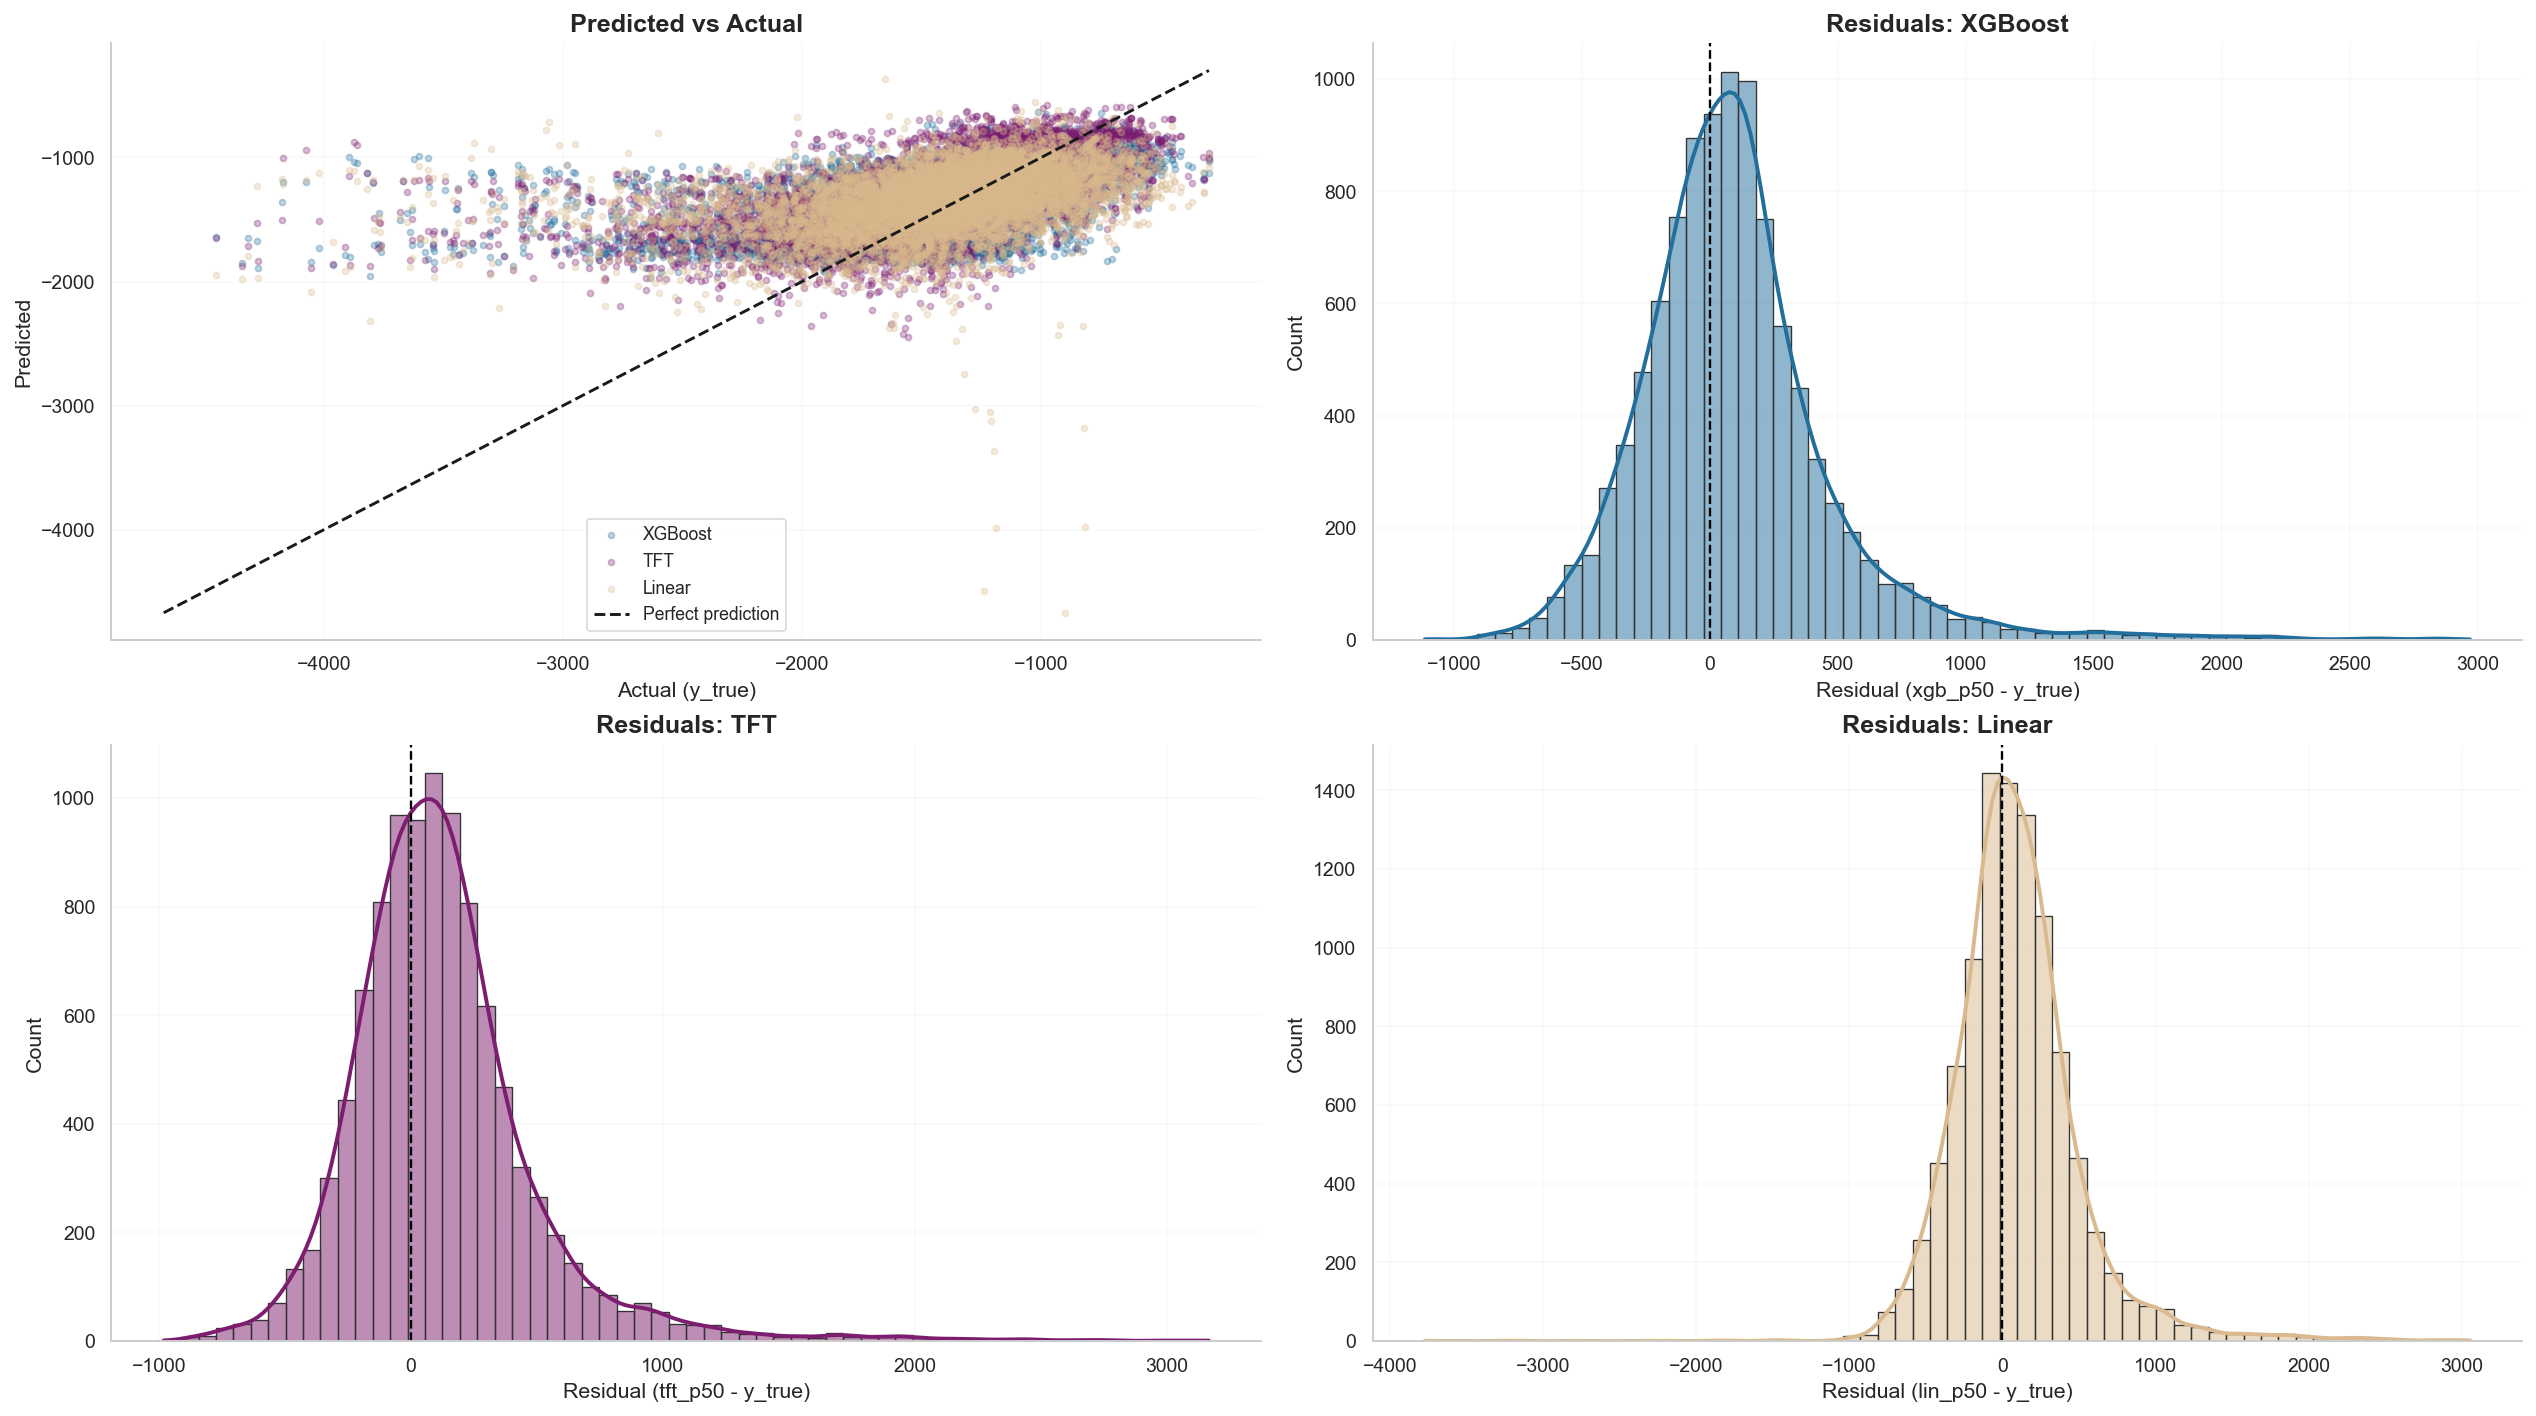

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Expected columns in df: target_time_utc, y_true, xgb_p50, tft_p50, lin_p50
d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50", "lin_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50", "lin_p50"]).sort_values("target_time_utc")

d["res_xgb"] = d["xgb_p50"] - d["y_true"]
d["res_tft"] = d["tft_p50"] - d["y_true"]
d["res_lin"] = d["lin_p50"] - d["y_true"]
xgb_color = THESIS_PALETTE["primary"]
tft_color = THESIS_PALETTE["tertiary"]
lin_color = THESIS_PALETTE["secondary"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)

# 1) Predicted vs Actual
ax = axes[0, 0]
ax.scatter(d["y_true"], d["xgb_p50"], s=10, alpha=0.3, color=xgb_color, label="XGBoost")
ax.scatter(d["y_true"], d["tft_p50"], s=10, alpha=0.3, color=tft_color, label="TFT")
ax.scatter(d["y_true"], d["lin_p50"], s=10, alpha=0.3, color=lin_color, label="Linear")
vmin = float(np.nanmin([d["y_true"].min(), d["xgb_p50"].min(), d["tft_p50"].min(), d["lin_p50"].min()]))
vmax = float(np.nanmax([d["y_true"].max(), d["xgb_p50"].max(), d["tft_p50"].max(), d["lin_p50"].max()]))
ax.plot([vmin, vmax], [vmin, vmax], "k--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual (y_true)")
ax.set_ylabel("Predicted")
ax.set_title("Predicted vs Actual")
ax.legend(frameon=True)

# 2) Residual histogram XGB
ax = axes[0, 1]
sns.histplot(d["res_xgb"], bins=60, kde=True, color=xgb_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (xgb_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: XGBoost")

# 3) Residual histogram TFT
ax = axes[1, 0]
sns.histplot(d["res_tft"], bins=60, kde=True, color=tft_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (tft_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: TFT")

# 4) Residual histogram Linear
ax = axes[1, 1]
sns.histplot(d["res_lin"], bins=60, kde=True, color=lin_color, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual (lin_p50 - y_true)")
ax.set_ylabel("Count")
ax.set_title("Residuals: Linear")

plt.show()

### 5. Temporal Error Regimes

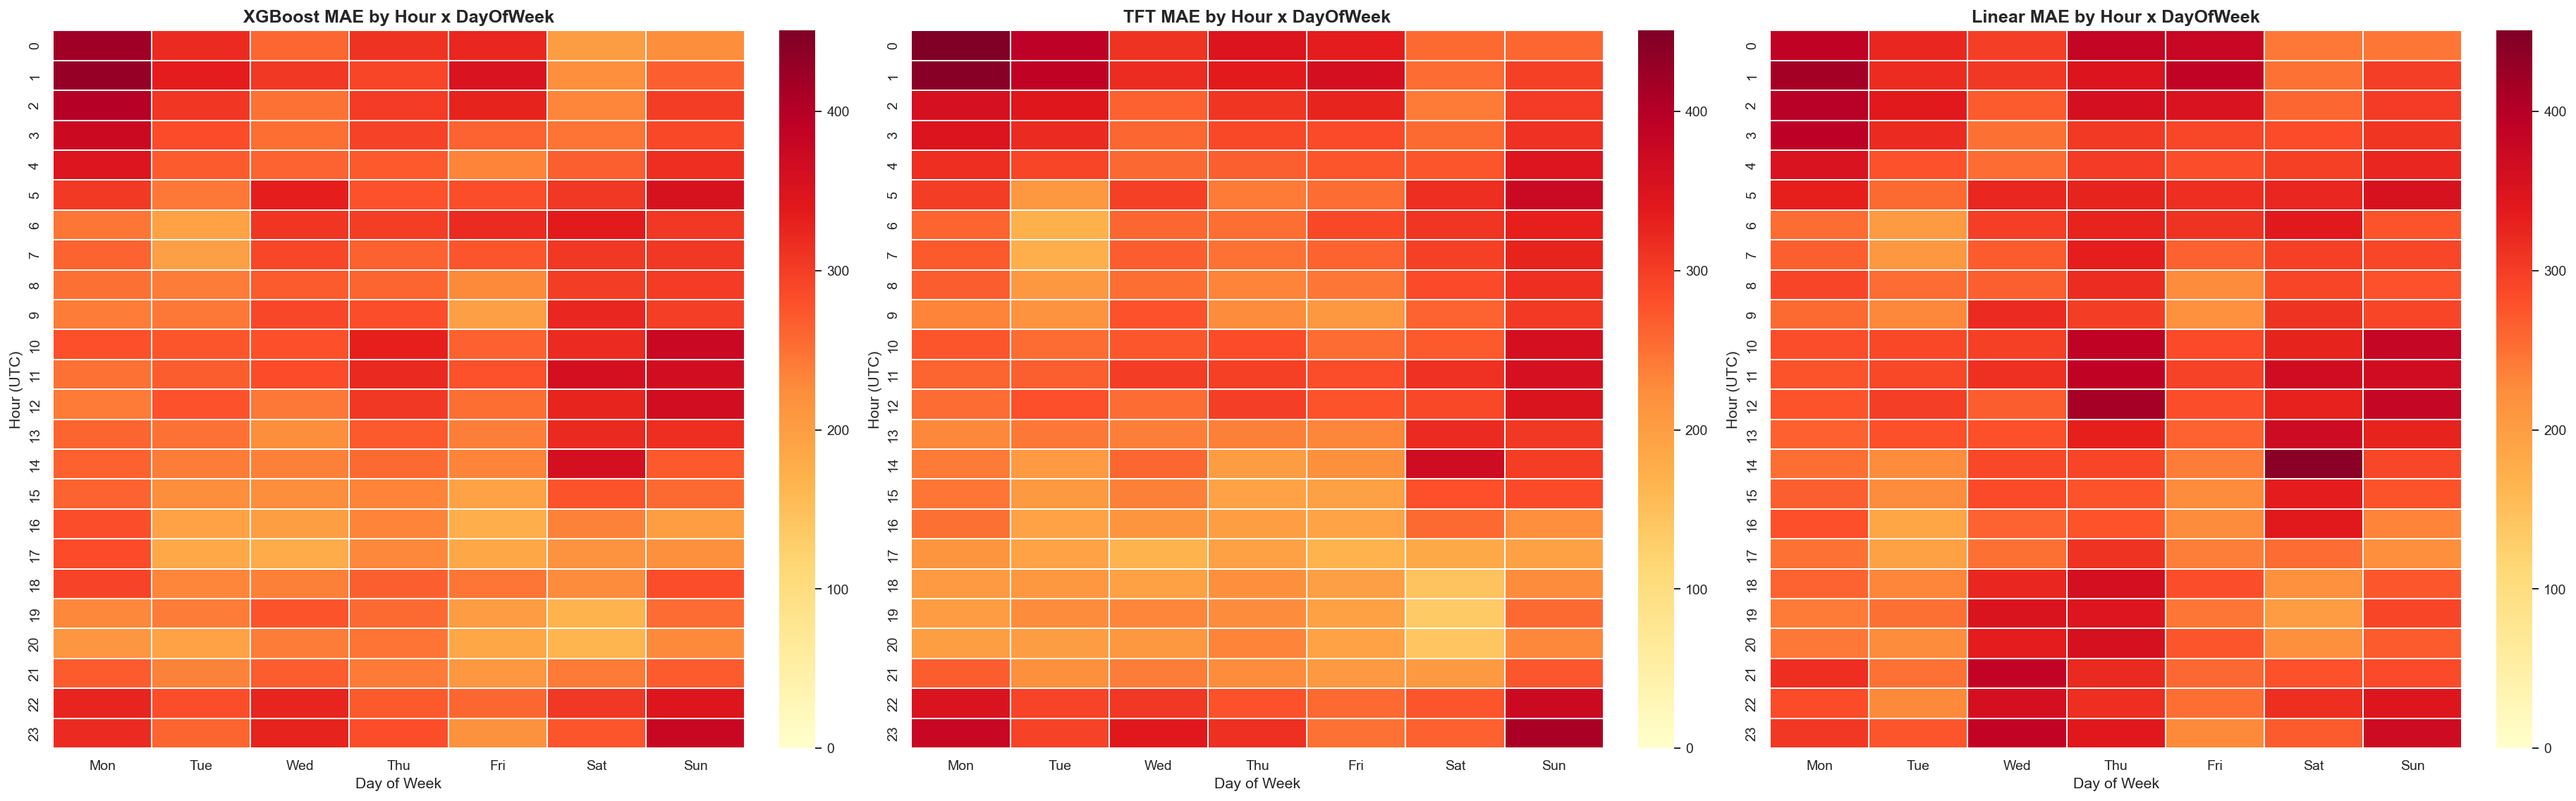

Delta Heatmap (XGB MAE - TFT MAE):


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,-31.5521,-72.0894,-51.7273,-39.4097,-9.8280,-55.2652,-34.5394
1,-14.4743,-53.8318,-12.7947,-45.5080,-8.2925,-30.8391,-29.9861
2,41.8645,-36.5330,-16.1247,-6.9948,2.3875,-10.7289,-2.2093
3,22.3670,-35.6832,-6.6419,6.9953,-23.5413,-8.7199,-23.8135
4,32.7593,-21.4712,6.4218,5.0739,-42.3186,-8.8328,-31.3738
5,3.9766,32.5302,37.1299,36.3024,27.4689,-10.4634,-18.6226
6,-16.1643,21.3810,49.0280,47.6283,32.5738,29.3338,-26.3675
7,-8.9860,24.0549,21.7073,16.1022,12.1720,7.5910,-23.1313
8,-18.8969,32.6683,18.4590,29.5574,-17.6985,13.3624,-13.4531


Delta Heatmap (XGB MAE - Linear MAE):


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,28.5253,-3.1324,-38.8797,-72.5972,-54.8624,-42.9447,-21.0535
1,12.6970,17.2289,-0.3958,-57.1380,-34.9899,-26.6611,-31.9334
2,2.1311,-31.3372,-21.1247,-58.9640,-25.2025,-28.1778,-1.2151
3,-20.9848,-34.4190,1.9102,-10.0736,-26.0237,-36.3336,-20.5349
4,-4.6931,-9.3907,9.8327,-30.3343,-49.6575,-30.2727,-9.1128
5,-27.8517,-13.0495,9.1670,-50.3847,-34.2678,-18.9233,-0.6856
6,-9.2768,-12.2139,9.8605,-28.6550,9.4789,-2.3310,28.3450
7,-2.7174,-10.3246,19.5309,-68.9100,10.2904,8.0335,15.4022
8,-41.8705,-13.5114,3.5019,-55.9691,2.0448,7.8319,22.6073


Delta Heatmap (TFT MAE - Linear MAE):


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
hour,,,,,,,
0,60.0775,68.9570,12.8475,-33.1876,-45.0344,12.3205,13.4859
1,27.1713,71.0607,12.3989,-11.6300,-26.6974,4.1780,-1.9474
2,-39.7334,5.1958,-5.0000,-51.9692,-27.5900,-17.4490,0.9942
3,-43.3518,1.2642,8.5522,-17.0689,-2.4824,-27.6136,3.2787
4,-37.4524,12.0805,3.4109,-35.4082,-7.3389,-21.4400,22.2610
5,-31.8283,-45.5798,-27.9629,-86.6872,-61.7367,-8.4599,17.9370
6,6.8875,-33.5949,-39.1675,-76.2833,-23.0949,-31.6648,54.7125
7,6.2685,-34.3795,-2.1765,-85.0122,-1.8817,0.4425,38.5334
8,-22.9736,-46.1797,-14.9571,-85.5265,19.7433,-5.5306,36.0604


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = globals()["df"].copy()
d["target_time_utc"] = pd.to_datetime(d["target_time_utc"], utc=True, errors="coerce")
for c in ["y_true", "xgb_p50", "tft_p50", "lin_p50"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")
d = d.dropna(subset=["target_time_utc", "y_true", "xgb_p50", "tft_p50", "lin_p50"]).sort_values("target_time_utc")

d["hour"] = d["target_time_utc"].dt.hour
d["dayofweek"] = d["target_time_utc"].dt.dayofweek  # Mon=0 ... Sun=6

d["ae_xgb"] = (d["xgb_p50"] - d["y_true"]).abs()
d["ae_tft"] = (d["tft_p50"] - d["y_true"]).abs()
d["ae_lin"] = (d["lin_p50"] - d["y_true"]).abs()

hour_index = list(range(24))
dow_index = list(range(7))
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

xgb_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_xgb"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_xgb")
    .reindex(index=hour_index, columns=dow_index)
)
tft_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_tft"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_tft")
    .reindex(index=hour_index, columns=dow_index)
)
lin_heat = (
    d.groupby(["hour", "dayofweek"], as_index=False)["ae_lin"].mean()
    .pivot(index="hour", columns="dayofweek", values="ae_lin")
    .reindex(index=hour_index, columns=dow_index)
)

xgb_heat.columns = dow_labels
tft_heat.columns = dow_labels
lin_heat.columns = dow_labels

vmax = float(np.nanmax([xgb_heat.to_numpy(), tft_heat.to_numpy(), lin_heat.to_numpy()]))
fig, axes = plt.subplots(1, 3, figsize=(26, 8), constrained_layout=True)

sns.heatmap(
    xgb_heat, ax=axes[0], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[0].set_title("XGBoost MAE by Hour x DayOfWeek")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Hour (UTC)")

sns.heatmap(
    tft_heat, ax=axes[1], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[1].set_title("TFT MAE by Hour x DayOfWeek")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Hour (UTC)")

sns.heatmap(
    lin_heat, ax=axes[2], cmap="YlOrRd", vmin=0, vmax=vmax,
    cbar=True, linewidths=0.2, linecolor="white"
)
axes[2].set_title("Linear MAE by Hour x DayOfWeek")
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Hour (UTC)")

plt.show()

delta_xgb_tft = xgb_heat - tft_heat
delta_xgb_lin = xgb_heat - lin_heat
delta_tft_lin = tft_heat - lin_heat

print("Delta Heatmap (XGB MAE - TFT MAE):")
display(delta_xgb_tft.round(4))
print("Delta Heatmap (XGB MAE - Linear MAE):")
display(delta_xgb_lin.round(4))
print("Delta Heatmap (TFT MAE - Linear MAE):")
display(delta_tft_lin.round(4))

### 6. Market-Specific Tail Performance Analysis

Tail metrics rows: 24


,category,pred_col,segment,segment_threshold_truth,model,model_id,n_segment,n_normal,segment_mae,normal_mae,tail_bias,spike_capture_rate,spike_pred_top20_threshold
0,DA Price,pred_da_price,high,141.015000,Linear,lin,1006,9052,48.155728,28.209967,-39.449068,0.791252,109.615309
1,DA Price,pred_da_price,high,141.015000,TFT,tft,1006,9052,47.715129,22.960502,-45.185396,0.908549,106.416544
2,DA Price,pred_da_price,high,141.015000,XGBoost,xgb,1006,9052,49.623726,19.323148,-42.242556,0.787276,111.897121
3,DA Price,pred_da_price,low,10.100000,Linear,lin,1007,9051,32.260439,29.976248,23.166459,NaN,NaN
4,DA Price,pred_da_price,low,10.100000,TFT,tft,1007,9051,51.004282,22.591821,26.569920,NaN,NaN
5,DA Price,pred_da_price,low,10.100000,XGBoost,xgb,1007,9051,33.760869,21.084677,33.057473,NaN,NaN
6,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1949.012400,Linear,lin,1006,9052,869.064800,232.346593,868.590536,NaN,NaN
7,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1949.012400,TFT,tft,1006,9052,837.796126,202.818383,835.882285,NaN,NaN
8,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1949.012400,XGBoost,xgb,1006,9052,837.976562,208.624492,837.976562,NaN,NaN
9,aFRR Activation Price,pred_afrr_activation_price_pos,low,1090.926517,Linear,lin,1006,9052,413.224176,369.531204,405.873264,NaN,NaN


Aggregated tail metrics (category x segment x model):


,category,segment,model,n_segment,segment_mae,normal_mae,tail_bias,spike_capture_rate
0,DA Price,high,Linear,1006,48.155728,28.209967,-39.449068,0.791252
1,DA Price,high,TFT,1006,47.715129,22.960502,-45.185396,0.908549
2,DA Price,high,XGBoost,1006,49.623726,19.323148,-42.242556,0.787276
3,DA Price,low,Linear,1007,32.260439,29.976248,23.166459,NaN
4,DA Price,low,TFT,1007,51.004282,22.591821,26.569920,NaN
5,DA Price,low,XGBoost,1007,33.760869,21.084677,33.057473,NaN
6,aFRR Activation Price,low,Linear,2012,641.144488,300.938898,637.231900,NaN
7,aFRR Activation Price,low,TFT,2012,611.054129,263.408175,608.405675,NaN
8,aFRR Activation Price,low,XGBoost,2012,595.753906,280.736297,595.340206,NaN
9,aFRR Activation Rate,high,Linear,2012,0.020276,0.006832,-0.020179,0.375249


Thesis-ready pivot table:


,category,segment,model,normal_mae,segment_mae,spike_capture_rate,tail_bias
0,DA Price,high,Linear,28.209967,48.155728,0.791252,-39.449068
1,DA Price,high,TFT,22.960502,47.715129,0.908549,-45.185396
2,DA Price,high,XGBoost,19.323148,49.623726,0.787276,-42.242556
3,DA Price,low,Linear,29.976248,32.260439,NaN,23.166459
4,DA Price,low,TFT,22.591821,51.004282,NaN,26.569920
5,DA Price,low,XGBoost,21.084677,33.760869,NaN,33.057473
6,aFRR Activation Price,low,Linear,300.938898,641.144488,NaN,637.231900
7,aFRR Activation Price,low,TFT,263.408175,611.054129,NaN,608.405675
8,aFRR Activation Price,low,XGBoost,280.736297,595.753906,NaN,595.340206
9,aFRR Activation Rate,high,Linear,0.006832,0.020276,0.375249,-0.020179


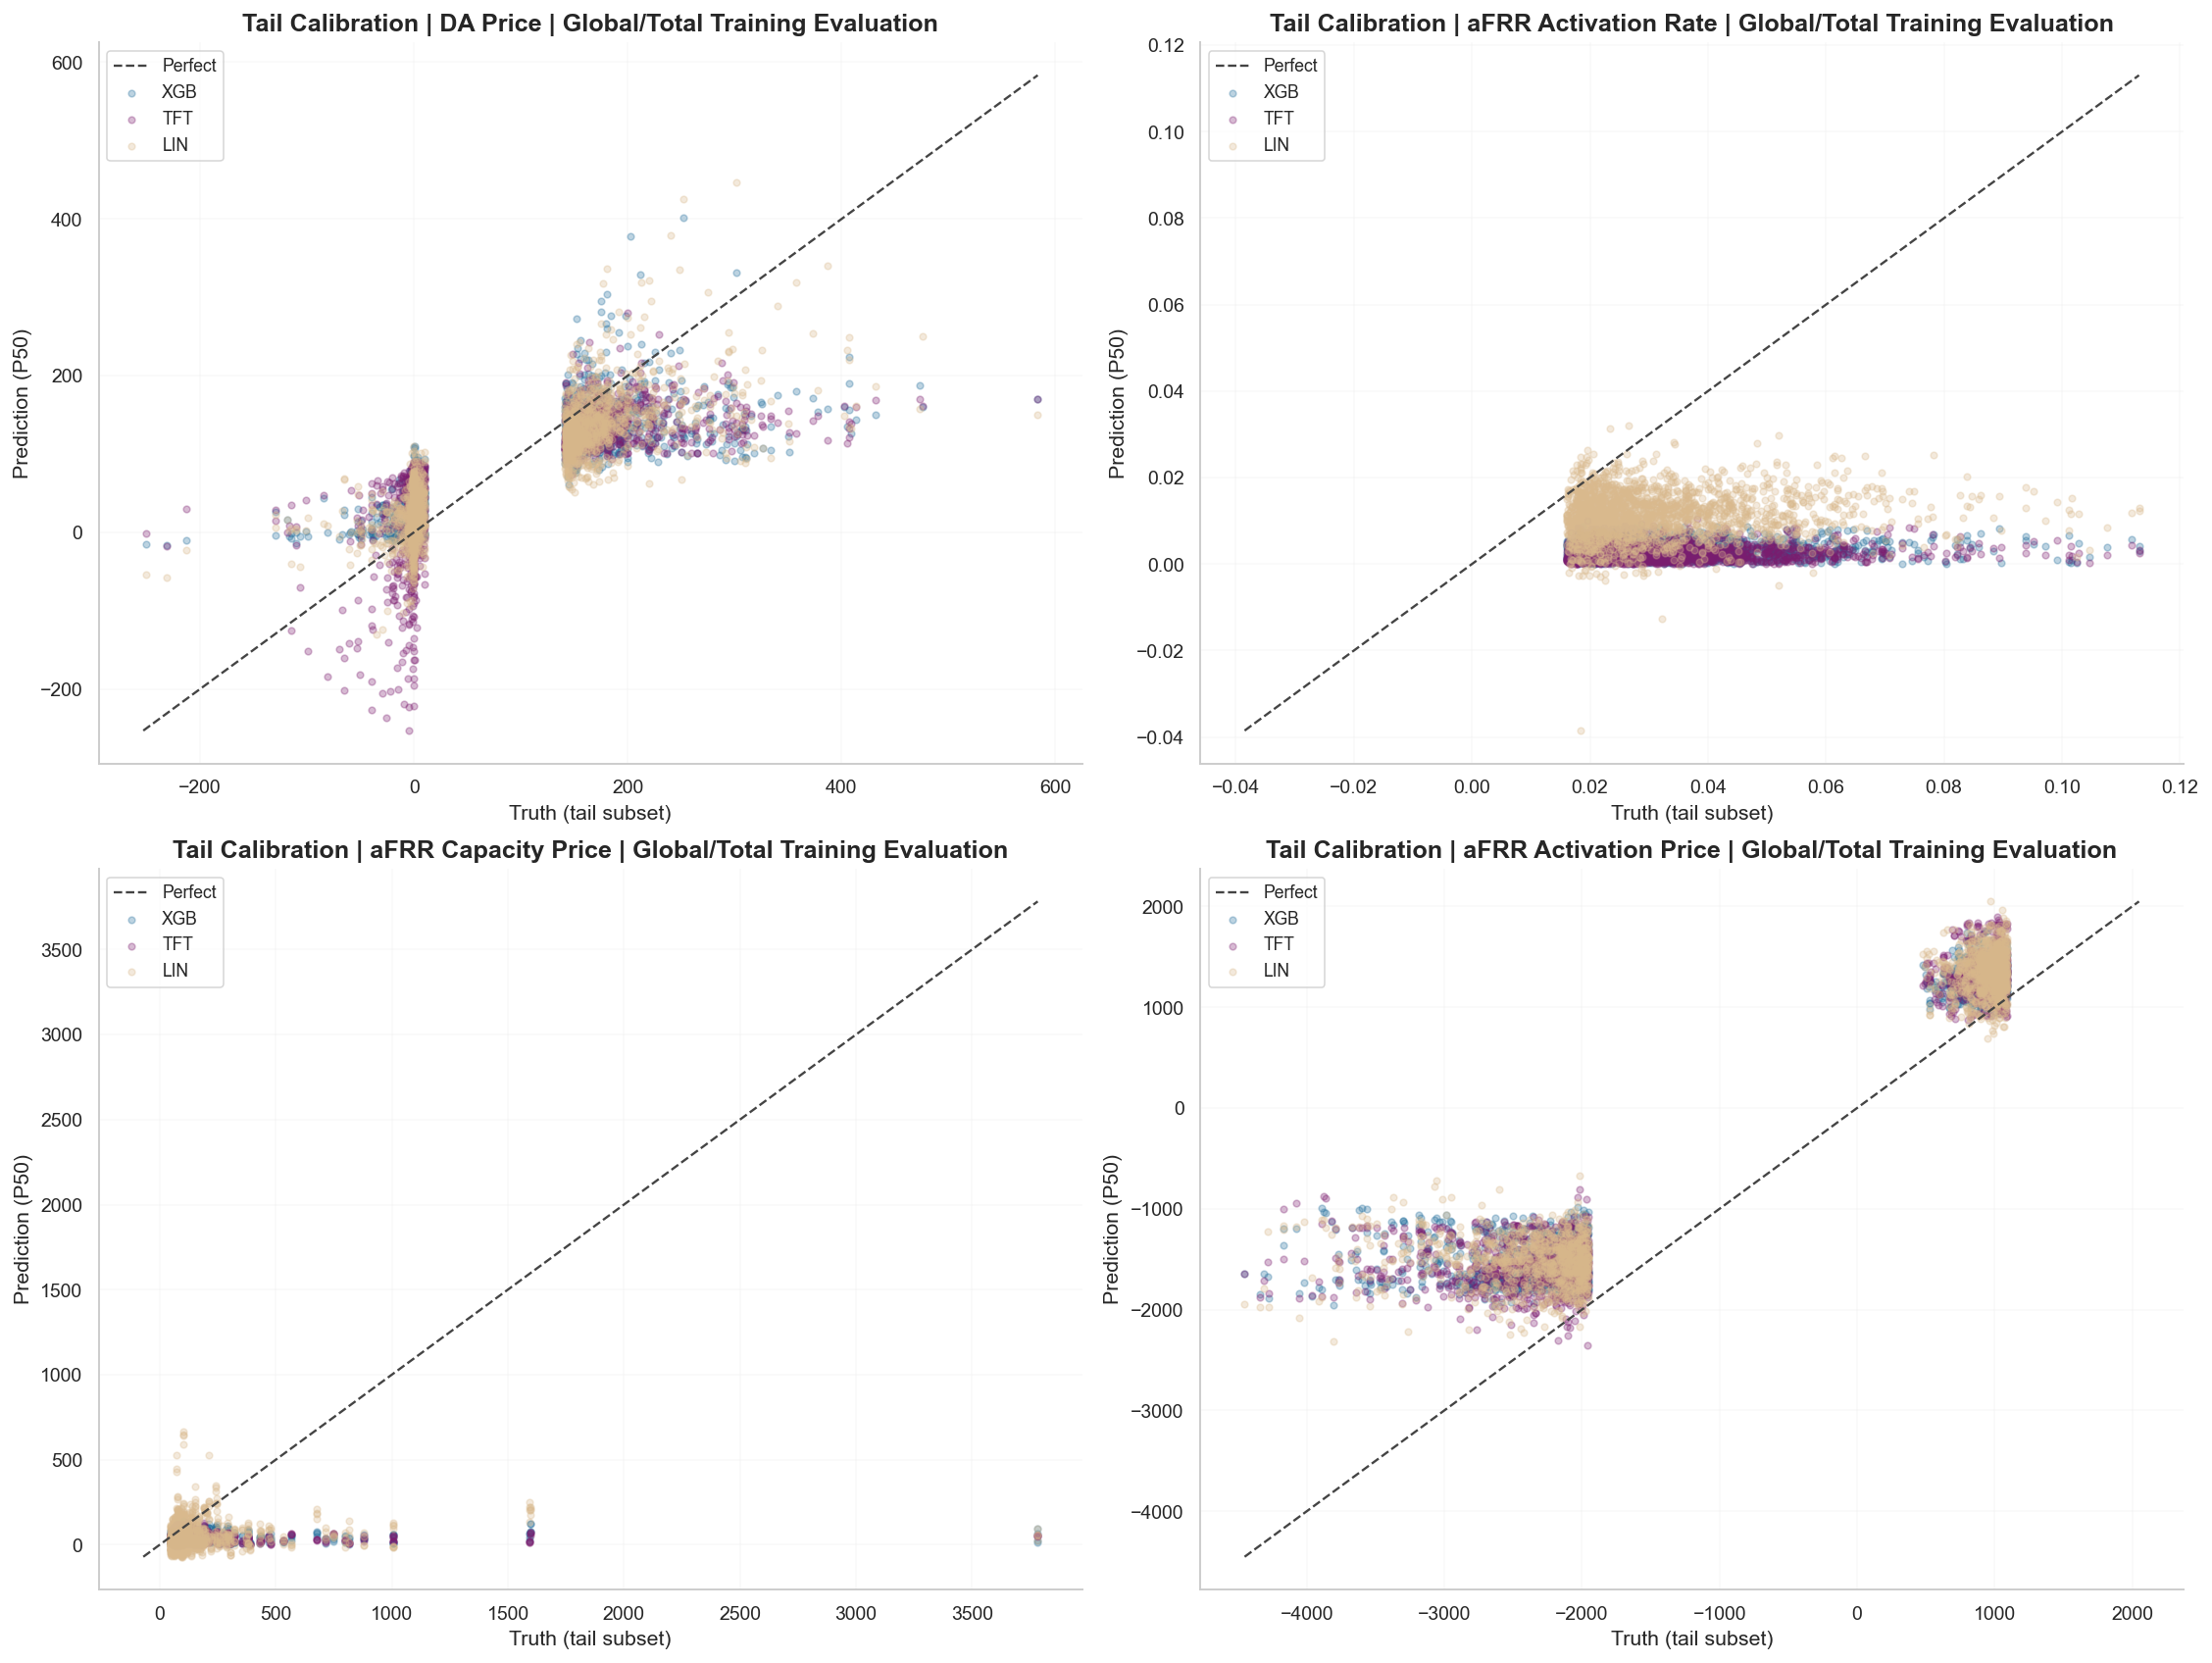

p10/p90 calibration summary (all targets, lead filter only):


,pred_col,category,model_id,quantile,n,empirical_coverage,coverage_gap,note
0,pred_afrr_activation_price_neg,aFRR Activation Price,xgb,0.1,10058,0.145456,0.045456,
1,pred_afrr_activation_price_neg,aFRR Activation Price,xgb,0.9,10058,0.955757,0.055757,
2,pred_afrr_activation_price_neg,aFRR Activation Price,tft,0.1,10058,0.181249,0.081249,
3,pred_afrr_activation_price_neg,aFRR Activation Price,tft,0.9,10058,0.851064,-0.048936,
4,pred_afrr_activation_price_neg,aFRR Activation Price,lin,0.1,0,NaN,NaN,quantile column not available
5,pred_afrr_activation_price_neg,aFRR Activation Price,lin,0.9,0,NaN,NaN,quantile column not available
6,pred_afrr_activation_price_pos,aFRR Activation Price,xgb,0.1,10058,0.036190,-0.063810,
7,pred_afrr_activation_price_pos,aFRR Activation Price,xgb,0.9,10058,0.876516,-0.023484,
8,pred_afrr_activation_price_pos,aFRR Activation Price,tft,0.1,10058,0.122688,0.022688,
9,pred_afrr_activation_price_pos,aFRR Activation Price,tft,0.9,10058,0.869059,-0.030941,


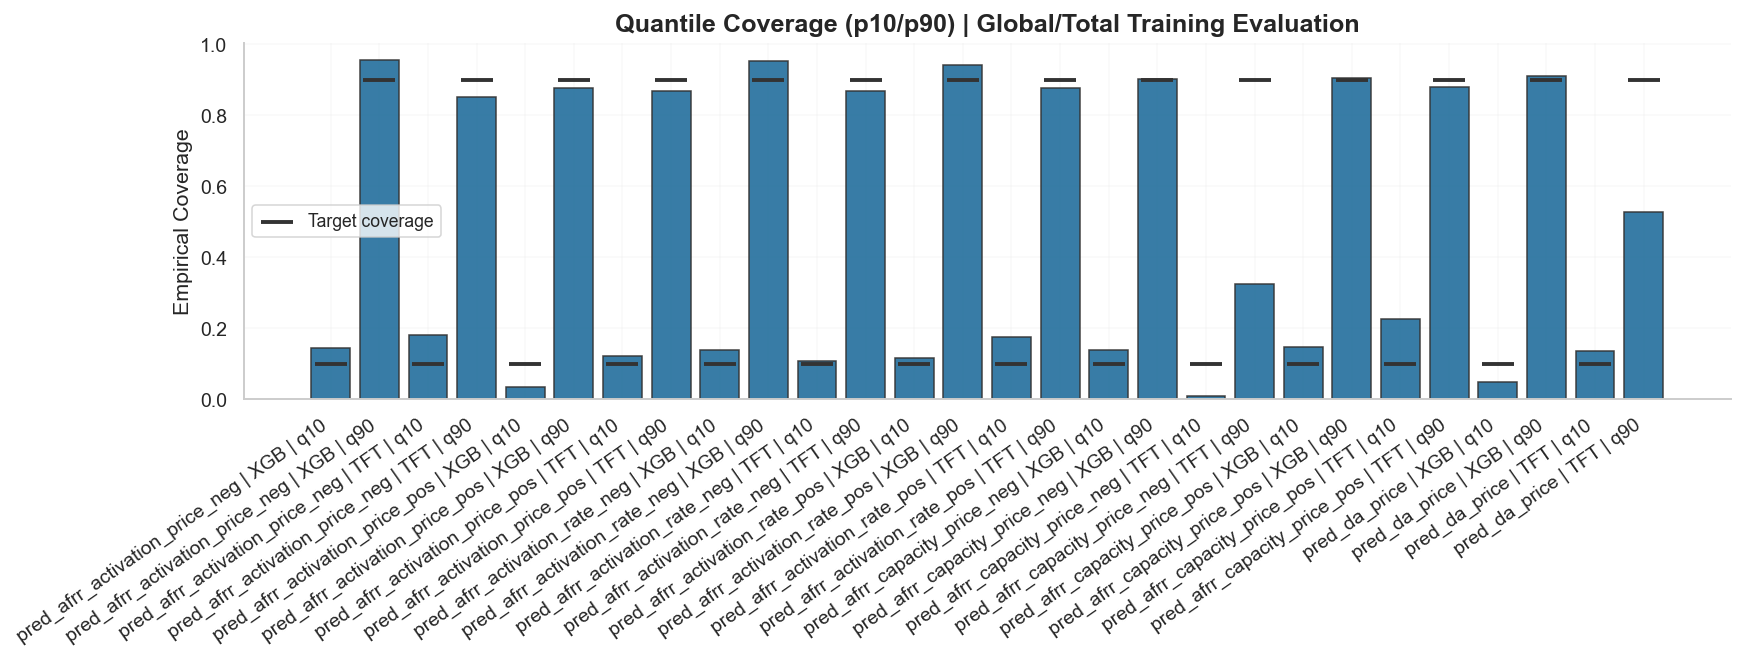

In [ ]:
from energy_trading.evaluation.gate_synced_analysis import build_tail_metrics, aggregate_tail_metrics, compute_quantile_coverage, plot_tail_calibration, plot_quantile_coverage_bars

# Tail analysis helpers + outputs (Market-Specific Tail Performance Analysis)
# DRY: uses reusable functions from energy_trading.evaluation.gate_synced_analysis

MODEL_INFO = {
    'xgb': {
        'label': 'XGBoost',
        'run_dir': RUN_DIR_XGB,
        'model_key': MODEL_KEY_XGB,
        'color': THESIS_PALETTE['primary'],
    },
    'tft': {
        'label': 'TFT',
        'run_dir': RUN_DIR_TFT,
        'model_key': MODEL_KEY_TFT,
        'color': THESIS_PALETTE['tertiary'],
    },
    'lin': {
        'label': 'Linear',
        'run_dir': RUN_DIR_LINEAR,
        'model_key': MODEL_KEY_LINEAR,
        'color': THESIS_PALETTE['secondary'],
    },
}
MODEL_IDS = ['xgb', 'tft', 'lin']
MODEL_LABELS = {mid: MODEL_INFO[mid]['label'] for mid in MODEL_IDS}
MODEL_COLORS = {mid: MODEL_INFO[mid]['color'] for mid in MODEL_IDS}
MAX_TAIL_POINTS_PER_GROUP = 2000
MAX_DISPLAY_ROWS = 400


def _build_model_merged(pred_col: str) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]
    base = truth_df[['timestamp_utc', truth_col]].copy().rename(
        columns={'timestamp_utc': 'target_time_utc', truth_col: 'y_true'}
    )
    base['target_time_utc'] = pd.to_datetime(base['target_time_utc'], utc=True, errors='coerce')
    merged = base

    for mid in MODEL_IDS:
        cfg = MODEL_INFO[mid]
        mdf = load_long_df(cfg['run_dir'], pred_col, cfg['model_key']).copy()
        if 'lead_time_h' in mdf.columns:
            mdf = mdf.loc[pd.to_numeric(mdf['lead_time_h'], errors='coerce') == float(LEAD)].copy()

        pred_col_name = 'p50' if 'p50' in mdf.columns else 'predicted_value'
        qcols = [q for q in ['p10','p20','p30','p40','p50','p60','p70','p80','p90'] if q in mdf.columns and q != pred_col_name]
        keep = ['snapshot_time_utc', 'target_time_utc', 'lead_time_h', pred_col_name, *qcols]
        mdf = mdf[keep].copy()

        rename = {pred_col_name: f'{mid}_p50'}
        for q in qcols:
            rename[q] = f'{mid}_{q}'
        mdf = mdf.rename(columns=rename)
        mdf = mdf.loc[:, ~mdf.columns.duplicated()].copy()

        if 'snapshot_time_utc' in merged.columns:
            mdf = mdf.drop(columns=[c for c in ['snapshot_time_utc', 'lead_time_h'] if c in mdf.columns], errors='ignore')
            merged = merged.merge(mdf, on='target_time_utc', how='inner')
        else:
            merged = merged.merge(mdf, on='target_time_utc', how='inner')

    merged = merged.loc[:, ~merged.columns.duplicated()].copy()
    merged['target_time_utc'] = pd.to_datetime(merged['target_time_utc'], utc=True, errors='coerce')
    if 'snapshot_time_utc' in merged.columns:
        merged['snapshot_time_utc'] = pd.to_datetime(merged['snapshot_time_utc'], utc=True, errors='coerce')
    return merged.sort_values('target_time_utc').reset_index(drop=True)


tail_parts = []
points_parts = []
cov_parts = []

for pred_col in COMMON_PRED_COLS:
    merged = _build_model_merged(pred_col)
    if merged.empty:
        continue

    tm, tp = build_tail_metrics(
        merged=merged,
        pred_col=pred_col,
        model_ids=MODEL_IDS,
        model_labels=MODEL_LABELS,
    )
    if not tm.empty:
        tail_parts.append(tm)
    if not tp.empty:
        points_parts.append(tp)

    cov = compute_quantile_coverage(
        merged,
        pred_col=pred_col,
        model_ids=MODEL_IDS,
        quantiles=(0.1, 0.9),
    )
    if not cov.empty:
        cov_parts.append(cov)


tail_metrics_df = pd.concat(tail_parts, ignore_index=True) if tail_parts else pd.DataFrame()
if tail_metrics_df.empty:
    raise ValueError('No tail metrics computed. Check COMMON_PRED_COLS / lead filtering / prediction files.')

print('Tail metrics rows:', len(tail_metrics_df))
tail_metrics_view = tail_metrics_df.sort_values(['category', 'pred_col', 'segment', 'model']).reset_index(drop=True)
display(tail_metrics_view.head(MAX_DISPLAY_ROWS))

agg_tail = aggregate_tail_metrics(tail_metrics_df)
print('Aggregated tail metrics (category x segment x model):')
display(agg_tail.head(MAX_DISPLAY_ROWS))

agg_tail_pivot = agg_tail.pivot_table(
    index=['category', 'segment', 'model'],
    values=['segment_mae', 'normal_mae', 'tail_bias', 'spike_capture_rate'],
    aggfunc='first'
).reset_index()
print('Thesis-ready pivot table:')
display(agg_tail_pivot.head(MAX_DISPLAY_ROWS))

points_df = pd.concat(points_parts, ignore_index=True) if points_parts else pd.DataFrame()
required_point_cols = {'category', 'pred_col', 'segment', 'model_id', 'y_true', 'y_pred'}
if not points_df.empty:
    # Normalize columns defensively to avoid schema/index drift across reruns.
    points_df = points_df.reset_index(drop=False)
    points_df.columns = [str(c) for c in points_df.columns]

if not points_df.empty and required_point_cols.issubset(set(points_df.columns)):
    # Simple global cap avoids fragile groupby/apply path that caused KeyError crashes.
    if len(points_df) > MAX_TAIL_POINTS_PER_GROUP * 24:
        points_df = points_df.sample(n=MAX_TAIL_POINTS_PER_GROUP * 24, random_state=42)
    points_df = points_df.reset_index(drop=True)
    plot_tail_calibration(
        points_df,
        model_colors=MODEL_COLORS,
        title_suffix='Global/Total Training Evaluation',
    )
else:
    print('Tail calibration scatter skipped: points_df missing required columns or empty.')

p90_calib_df = pd.concat(cov_parts, ignore_index=True) if cov_parts else pd.DataFrame()
print('p10/p90 calibration summary (all targets, lead filter only):')
display(p90_calib_df.head(MAX_DISPLAY_ROWS))

plot_quantile_coverage_bars(
    p90_calib_df,
    title_suffix='Global/Total Training Evaluation',
)


### 7. Final Decision Table (Global + Gate Metrics)

This section aggregates target-level model metrics into one decision table for simulation model selection.

Included per target/model:
- Global: MAE, RMSE, wMAPE, MBE, over-prediction ratio, directional accuracy
- Gate-closure metrics (when applicable): gate MAE / gate RMSE / gate rows
- Recommendation rule: prefer lowest gate MAE for gate-critical targets (DA, aFRR capacity), otherwise lowest global MAE (directional accuracy as tiebreak)


In [ ]:
from energy_trading.evaluation.metrics import compute_forecast_metrics, compute_gate_closure_metrics, gate_hour_for_target

MODEL_SPECS = [
    ("xgb", "XGBoost", RUN_DIR_XGB, MODEL_KEY_XGB, THESIS_PALETTE["primary"]),
    ("tft", "TFT", RUN_DIR_TFT, MODEL_KEY_TFT, THESIS_PALETTE["tertiary"]),
    ("lin", "Linear", RUN_DIR_LINEAR, MODEL_KEY_LINEAR, THESIS_PALETTE["secondary"]),
]


def _target_display_name(pred_col: str) -> str:
    p = pred_col.lower()
    if p == 'pred_da_price':
        return 'DA Price'
    if 'activation_rate' in p:
        return 'Activation Rate'
    if 'capacity_price' in p:
        return 'Capacity Price'
    if 'activation_price' in p:
        return 'Activation Price'
    return pred_col


def _model_long_lead_df(run_dir: Path, model_key: str, pred_col: str, lead: int) -> pd.DataFrame:
    d = load_long_df(run_dir, pred_col, model_key).copy()
    if 'lead_time_h' in d.columns:
        d = d.loc[pd.to_numeric(d['lead_time_h'], errors='coerce') == float(lead)].copy()
    return d


def _decision_sort_value(row: pd.Series) -> tuple:
    gate_mae = pd.to_numeric(pd.Series([row.get('gate_mae')]), errors='coerce').iloc[0]
    mae = pd.to_numeric(pd.Series([row.get('mae')]), errors='coerce').iloc[0]
    da = pd.to_numeric(pd.Series([row.get('directional_accuracy')]), errors='coerce').iloc[0]

    # Gate-critical targets: DA + capacity use gate MAE as primary sort key when available.
    is_gate_critical = bool(row.get('is_gate_critical', False))
    if is_gate_critical and pd.notna(gate_mae):
        primary = float(gate_mae)
    else:
        primary = float(mae) if pd.notna(mae) else float('inf')

    # Higher directional accuracy is better => use negative for ascending sort.
    secondary = float(-da) if pd.notna(da) else float('inf')
    tertiary = float(mae) if pd.notna(mae) else float('inf')
    return (primary, secondary, tertiary)


rows = []
for pred_col in COMMON_PRED_COLS:
    truth_col = TRUTH_COL_BY_PRED[pred_col]
    target_name = _target_display_name(pred_col)
    gate_h = gate_hour_for_target(truth_col)
    is_gate_critical = gate_h is not None

    for model_id, model_label, run_dir, model_key, _ in MODEL_SPECS:
        long_df = _model_long_lead_df(run_dir, model_key, pred_col, LEAD)
        if long_df.empty:
            rows.append({
                'pred_col': pred_col,
                'target': target_name,
                'truth_col': truth_col,
                'model': model_label,
                'model_id': model_id,
                'is_gate_critical': is_gate_critical,
                'gate_hour_local': gate_h,
                'error': 'empty long df at selected lead',
            })
            continue

        pred_value_col = 'p50' if 'p50' in long_df.columns else 'predicted_value'
        if pred_value_col not in long_df.columns:
            rows.append({
                'pred_col': pred_col,
                'target': target_name,
                'truth_col': truth_col,
                'model': model_label,
                'model_id': model_id,
                'is_gate_critical': is_gate_critical,
                'gate_hour_local': gate_h,
                'error': 'missing p50/predicted_value',
            })
            continue

        d_eval = long_df[['target_time_utc', pred_value_col]].copy().rename(columns={pred_value_col: 'y_pred'})
        t_eval = truth_df[['timestamp_utc', truth_col]].copy().rename(columns={'timestamp_utc': 'target_time_utc', truth_col: 'y_true'})
        merged = d_eval.merge(t_eval, on='target_time_utc', how='left')

        suite = compute_forecast_metrics(merged, y_true_col='y_true', y_pred_col='y_pred')

        gate_metrics = {}
        if gate_h is not None:
            gate_pred = long_df.copy()
            if 'predicted_value' not in gate_pred.columns and 'p50' in gate_pred.columns:
                gate_pred['predicted_value'] = pd.to_numeric(gate_pred['p50'], errors='coerce')
            gate_metrics = compute_gate_closure_metrics(
                pred_long_df=gate_pred,
                truth_df=truth_df,
                y_true_col=truth_col,
                y_pred_col='predicted_value',
                gate_hour_local=int(gate_h),
                timezone='Europe/Berlin',
                snapshot_col='snapshot_time_utc',
                target_time_col='target_time_utc',
            )

        rows.append({
            'pred_col': pred_col,
            'target': target_name,
            'truth_col': truth_col,
            'model': model_label,
            'model_id': model_id,
            'is_gate_critical': is_gate_critical,
            'gate_hour_local': gate_h,
            'n_rows_scored': suite.get('n_rows_scored'),
            'mae': suite.get('mae'),
            'rmse': suite.get('rmse'),
            'wmape': suite.get('wmape'),
            'mbe': suite.get('mbe'),
            'over_prediction_ratio': suite.get('over_prediction_ratio'),
            'directional_accuracy': suite.get('directional_accuracy'),
            'gate_n_rows': gate_metrics.get('n_rows_gate') if gate_metrics else np.nan,
            'gate_mae': gate_metrics.get('mae_gate') if gate_metrics else np.nan,
            'gate_rmse': gate_metrics.get('rmse_gate') if gate_metrics else np.nan,
            'error': '',
        })


decision_df = pd.DataFrame(rows)

if decision_df.empty:
    raise ValueError('Decision table is empty.')

# Rank and recommendation per target.
decision_df['sort_key'] = decision_df.apply(_decision_sort_value, axis=1)
decision_df = decision_df.sort_values(['pred_col', 'sort_key']).reset_index(drop=True)
decision_df['rank_within_target'] = decision_df.groupby('pred_col').cumcount() + 1
decision_df['recommended_for_simulation'] = decision_df['rank_within_target'] == 1

# Pretty display
disp_cols = [
    'target', 'pred_col', 'model', 'rank_within_target', 'recommended_for_simulation',
    'mae', 'rmse', 'wmape', 'mbe', 'over_prediction_ratio', 'directional_accuracy',
    'gate_hour_local', 'gate_n_rows', 'gate_mae', 'gate_rmse', 'error'
]

print('Final decision table (per-target ranking):')
display(decision_df[disp_cols].sort_values(['target', 'rank_within_target']).reset_index(drop=True))

best_models_df = decision_df[decision_df['recommended_for_simulation']].copy()
print('Recommended model per target:')
display(best_models_df[['target', 'pred_col', 'model', 'mae', 'gate_mae', 'directional_accuracy']].sort_values('target').reset_index(drop=True))

# Save artifacts for reporting
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
out_csv = BENCHMARK_DIR / 'final_decision_table.csv'
out_best_csv = BENCHMARK_DIR / 'final_decision_recommended_models.csv'
decision_df.drop(columns=['sort_key']).to_csv(out_csv, index=False)
best_models_df.drop(columns=['sort_key']).to_csv(out_best_csv, index=False)
print('Wrote decision tables:')
print('-', out_csv)
print('-', out_best_csv)


Final decision table (per-target ranking):


,target,pred_col,model,rank_within_target,recommended_for_simulation,mae,rmse,wmape,mbe,over_prediction_ratio,directional_accuracy,gate_hour_local,gate_n_rows,gate_mae,gate_rmse,error
0,Activation Price,pred_afrr_activation_price_neg,TFT,1,True,256.200713,370.637112,0.183814,102.287369,0.606096,0.564336,NaN,NaN,NaN,NaN,
1,Activation Price,pred_afrr_activation_price_pos,TFT,1,True,337.752292,497.563591,0.211118,-129.186496,0.414109,0.554128,NaN,NaN,NaN,NaN,
2,Activation Price,pred_afrr_activation_price_neg,XGBoost,2,False,272.143120,400.855437,0.190463,99.074326,0.588375,0.513441,NaN,NaN,NaN,NaN,
3,Activation Price,pred_afrr_activation_price_pos,XGBoost,2,False,352.869660,504.334872,0.218482,-216.558901,0.319877,0.534868,NaN,NaN,NaN,NaN,
4,Activation Price,pred_afrr_activation_price_neg,Linear,3,False,285.566170,404.591050,0.205042,93.197999,0.592800,0.538971,NaN,NaN,NaN,NaN,
5,Activation Price,pred_afrr_activation_price_pos,Linear,3,False,371.030323,538.934247,0.232117,-141.152175,0.420857,0.520003,NaN,NaN,NaN,NaN,
6,Activation Rate,pred_afrr_activation_rate_neg,XGBoost,1,True,0.005088,0.010248,0.947711,-0.002967,0.593434,0.449261,NaN,NaN,NaN,NaN,
7,Activation Rate,pred_afrr_activation_rate_pos,TFT,1,True,0.005555,0.011475,0.931553,-0.003846,0.506319,0.513853,NaN,NaN,NaN,NaN,
8,Activation Rate,pred_afrr_activation_rate_neg,TFT,2,False,0.005317,0.010458,0.945795,-0.003585,0.513193,0.496424,NaN,NaN,NaN,NaN,
9,Activation Rate,pred_afrr_activation_rate_pos,XGBoost,2,False,0.005603,0.011346,0.945657,-0.003687,0.524499,0.488642,NaN,NaN,NaN,NaN,


Recommended model per target:


,target,pred_col,model,mae,gate_mae,directional_accuracy
0,Activation Price,pred_afrr_activation_price_neg,TFT,256.200713,NaN,0.564336
1,Activation Price,pred_afrr_activation_price_pos,TFT,337.752292,NaN,0.554128
2,Activation Rate,pred_afrr_activation_rate_neg,XGBoost,0.005088,NaN,0.449261
3,Activation Rate,pred_afrr_activation_rate_pos,TFT,0.005555,NaN,0.513853
4,Capacity Price,pred_afrr_capacity_price_neg,XGBoost,12.907957,8.017479,0.160401
5,Capacity Price,pred_afrr_capacity_price_pos,TFT,13.765591,10.408800,0.215193
6,DA Price,pred_da_price,XGBoost,22.367876,21.811153,0.719075


Wrote decision tables:
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_decision_table.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_decision_recommended_models.csv


### 8. Per-Target Verdict Table (Behavior + Trading Relevance)

This section unifies model-selection evidence into one concise per-target verdict table.

Inputs merged:
- Final per-target ranking from Section 7 (`decision_df`)
- Tail/spike behavior from Section 6 (`tail_metrics_df`)
- Activation-rate p90 calibration in high-imbalance periods (`p90_calib_df`)
- Horizon degradation proxy (MAE h_last / MAE h1)

Output artifacts:
- `final_per_target_verdict_table.csv`
- `final_per_target_verdict_table.json`


In [ ]:
# Build concise per-target verdict table
if 'decision_df' not in globals() or decision_df is None or decision_df.empty:
    raise RuntimeError('Run Section 7 first: decision_df not found or empty.')

if 'tail_metrics_df' not in globals() or tail_metrics_df is None or tail_metrics_df.empty:
    raise RuntimeError('Run Section 6 first: tail_metrics_df not found or empty.')

# Optional calibration table (only activation-rate targets + models with p90)
p90_df = globals().get('p90_calib_df', pd.DataFrame()).copy()
if p90_df is None:
    p90_df = pd.DataFrame()

model_id_to_label = {'xgb': 'XGBoost', 'tft': 'TFT', 'lin': 'Linear'}
label_to_model_id = {v: k for k, v in model_id_to_label.items()}

# Aggregate tail diagnostics to target/model level.
_n_tail_col = 'n_segment' if 'n_segment' in tail_metrics_df.columns else ('n_tail' if 'n_tail' in tail_metrics_df.columns else None)
if _n_tail_col is None:
    raise KeyError("tail_metrics_df must contain either 'n_segment' or 'n_tail'.")

tail_agg = (
    tail_metrics_df
    .groupby(['pred_col', 'model'], as_index=False)
    .agg(
        tail_mae_mean=('segment_mae', 'mean'),
        normal_mae_mean=('normal_mae', 'mean'),
        tail_bias_mean=('tail_bias', 'mean'),
        spike_capture_rate_mean=('spike_capture_rate', 'mean'),
        n_tail_total=(_n_tail_col, 'sum'),
    )
)
tail_agg['tail_mae_ratio'] = tail_agg['tail_mae_mean'] / tail_agg['normal_mae_mean']

# Horizon degradation proxy from per-model lead curves.
hrows = []
for pred_col in COMMON_PRED_COLS:
    for mid, mlabel, run_dir, model_key, _ in MODEL_SPECS:
        mdf = compute_metrics_by_lead_for_model(pred_col, run_dir, model_key)
        if mdf.empty:
            hrows.append({'pred_col': pred_col, 'model': mlabel, 'mae_h1': np.nan, 'mae_h_last': np.nan, 'mae_horizon_ratio': np.nan})
            continue
        mdf = mdf.sort_values('lead_time_h').reset_index(drop=True)
        mae_h1 = float(mdf.loc[mdf['lead_time_h'] == mdf['lead_time_h'].min(), 'mae'].iloc[0]) if not mdf.empty else np.nan
        mae_h_last = float(mdf['mae'].iloc[-1]) if not mdf.empty else np.nan
        ratio = (mae_h_last / mae_h1) if (np.isfinite(mae_h1) and mae_h1 > 1e-12 and np.isfinite(mae_h_last)) else np.nan
        hrows.append({'pred_col': pred_col, 'model': mlabel, 'mae_h1': mae_h1, 'mae_h_last': mae_h_last, 'mae_horizon_ratio': ratio})

horizon_agg = pd.DataFrame(hrows)

# Recommended model rows (one per target).
best = decision_df.loc[decision_df['recommended_for_simulation']].copy()
if best.empty:
    raise RuntimeError('No recommended rows in decision_df (expected one per target).')

verdict = best[['target', 'pred_col', 'truth_col', 'model', 'model_id', 'is_gate_critical', 'gate_hour_local', 'mae', 'rmse', 'wmape', 'mbe', 'over_prediction_ratio', 'directional_accuracy', 'gate_mae', 'gate_rmse', 'gate_n_rows']].copy()

# Backfill gate metrics from artifact when in-memory columns are empty/misaligned.
gate_path = BENCHMARK_DIR / 'gate_time_target_mae.csv'
if gate_path.exists():
    gate_df = pd.read_csv(gate_path)
    if {'pred_col', 'model_id', 'gate_mae_mean', 'gate_rmse_mean', 'n_total'}.issubset(gate_df.columns):
        gate_df = gate_df.rename(columns={'gate_mae_mean': 'gate_mae_fix', 'gate_rmse_mean': 'gate_rmse_fix', 'n_total': 'gate_n_rows_fix'})
        verdict = verdict.merge(gate_df[['pred_col', 'model_id', 'gate_mae_fix', 'gate_rmse_fix', 'gate_n_rows_fix']], on=['pred_col', 'model_id'], how='left')
        for c, cfix in [('gate_mae', 'gate_mae_fix'), ('gate_rmse', 'gate_rmse_fix'), ('gate_n_rows', 'gate_n_rows_fix')]:
            verdict[c] = pd.to_numeric(verdict[c], errors='coerce')
            verdict[cfix] = pd.to_numeric(verdict[cfix], errors='coerce')
            verdict[c] = verdict[c].where(verdict[c].notna(), verdict[cfix])
        verdict = verdict.drop(columns=['gate_mae_fix', 'gate_rmse_fix', 'gate_n_rows_fix'], errors='ignore')

verdict = verdict.merge(
    tail_agg[['pred_col', 'model', 'tail_mae_mean', 'normal_mae_mean', 'tail_mae_ratio', 'tail_bias_mean', 'spike_capture_rate_mean', 'n_tail_total']],
    on=['pred_col', 'model'],
    how='left',
)

verdict = verdict.merge(
    horizon_agg[['pred_col', 'model', 'mae_h1', 'mae_h_last', 'mae_horizon_ratio']],
    on=['pred_col', 'model'],
    how='left',
)

# Activation-rate p90 coverage lookup for chosen model.
if not p90_df.empty:
    p90_df = p90_df.copy()
    if 'model_id' not in p90_df.columns and 'model' in p90_df.columns:
        p90_df['model_id'] = p90_df['model'].map(label_to_model_id)
    if 'model' not in p90_df.columns and 'model_id' in p90_df.columns:
        p90_df['model'] = p90_df['model_id'].map(model_id_to_label)

    p90_df['model_id'] = p90_df.get('model_id', pd.Series(index=p90_df.index, dtype='object')).astype(str).str.lower()
    p90_df = p90_df[p90_df['model_id'].isin(model_id_to_label.keys())].copy()

    p90_df = p90_df.rename(columns={'p90_coverage_in_high_imbalance': 'activation_rate_p90_coverage_high_imbalance'})
    if 'activation_rate_p90_coverage_high_imbalance' in p90_df.columns:
        verdict = verdict.merge(
            p90_df[['pred_col', 'model_id', 'activation_rate_p90_coverage_high_imbalance']].drop_duplicates(),
            on=['pred_col', 'model_id'],
            how='left',
        )
    else:
        verdict['activation_rate_p90_coverage_high_imbalance'] = np.nan
else:
    verdict['activation_rate_p90_coverage_high_imbalance'] = np.nan


def _risk_band(row: pd.Series) -> str:
    flags = 0
    tmr = pd.to_numeric(pd.Series([row.get('tail_mae_ratio')]), errors='coerce').iloc[0]
    scr = pd.to_numeric(pd.Series([row.get('spike_capture_rate_mean')]), errors='coerce').iloc[0]
    hrr = pd.to_numeric(pd.Series([row.get('mae_horizon_ratio')]), errors='coerce').iloc[0]
    cov = pd.to_numeric(pd.Series([row.get('activation_rate_p90_coverage_high_imbalance')]), errors='coerce').iloc[0]

    if np.isfinite(tmr) and tmr > 1.8:
        flags += 1
    if np.isfinite(scr) and scr < 0.40:
        flags += 1
    if np.isfinite(hrr) and hrr > 1.6:
        flags += 1
    if 'activation_rate' in str(row.get('pred_col', '')) and np.isfinite(cov) and (cov < 0.80 or cov > 0.98):
        flags += 1

    if flags >= 2:
        return 'High'
    if flags == 1:
        return 'Medium'
    return 'Low'


def _key_assumption(row: pd.Series) -> str:
    if bool(row.get('is_gate_critical', False)):
        return 'Gate-closure execution quality is prioritized.'
    if 'activation_rate' in str(row.get('pred_col', '')):
        return 'Activation uncertainty is handled via quantile-aware safeguards.'
    return 'Global forecast error is representative for trading decisions.'


def _expected_behavior(row: pd.Series) -> str:
    tmr = pd.to_numeric(pd.Series([row.get('tail_mae_ratio')]), errors='coerce').iloc[0]
    hrr = pd.to_numeric(pd.Series([row.get('mae_horizon_ratio')]), errors='coerce').iloc[0]
    if np.isfinite(tmr) and tmr > 1.8:
        return 'Tail misses likely during stress windows; expect lower realized PnL in spikes.'
    if np.isfinite(hrr) and hrr > 1.6:
        return 'Forecast decays with horizon; expect weaker long-horizon dispatch quality.'
    return 'Stable behavior expected with moderate forecast-to-PnL translation risk.'


verdict['risk_level'] = verdict.apply(_risk_band, axis=1)
verdict['key_assumption'] = verdict.apply(_key_assumption, axis=1)
verdict['expected_simulation_behavior'] = verdict.apply(_expected_behavior, axis=1)

order_cols = [
    'target', 'pred_col', 'model', 'risk_level',
    'mae', 'rmse', 'wmape', 'mbe', 'directional_accuracy',
    'gate_hour_local', 'gate_mae', 'gate_rmse',
    'tail_mae_mean', 'normal_mae_mean', 'tail_mae_ratio', 'tail_bias_mean', 'spike_capture_rate_mean',
    'mae_h1', 'mae_h_last', 'mae_horizon_ratio',
    'activation_rate_p90_coverage_high_imbalance',
    'key_assumption', 'expected_simulation_behavior',
]

verdict = verdict[order_cols].sort_values('target').reset_index(drop=True)

# Presentational N/A handling only for display.
verdict_display = verdict.copy()
for c in ['spike_capture_rate_mean', 'activation_rate_p90_coverage_high_imbalance', 'gate_hour_local', 'gate_mae', 'gate_rmse']:
    if c in verdict_display.columns:
        verdict_display[c] = verdict_display[c].where(verdict_display[c].notna(), 'N/A')

print('Per-target verdict table:')
display(verdict_display)

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
out_csv = BENCHMARK_DIR / 'final_per_target_verdict_table.csv'
out_json = BENCHMARK_DIR / 'final_per_target_verdict_table.json'
verdict.to_csv(out_csv, index=False)
out_json.write_text(verdict.to_json(orient='records', indent=2), encoding='utf-8')
print('Wrote verdict artifacts:')
print('-', out_csv)
print('-', out_json)


Per-target verdict table:


,target,pred_col,model,risk_level,mae,rmse,wmape,mbe,directional_accuracy,gate_hour_local,...,normal_mae_mean,tail_mae_ratio,tail_bias_mean,spike_capture_rate_mean,mae_h1,mae_h_last,mae_horizon_ratio,activation_rate_p90_coverage_high_imbalance,key_assumption,expected_simulation_behavior
0,Activation Price,pred_afrr_activation_price_neg,TFT,Medium,256.200713,370.637112,0.183814,102.287369,0.564336,N/A,...,202.818383,4.130770,835.882285,N/A,172.821155,266.307565,1.540943,N/A,Global forecast error is representative for tr...,Tail misses likely during stress windows; expe...
1,Activation Price,pred_afrr_activation_price_pos,TFT,Low,337.752292,497.563591,0.211118,-129.186496,0.554128,N/A,...,323.997967,1.186156,380.929064,N/A,241.237436,343.581674,1.424247,N/A,Global forecast error is representative for tr...,Stable behavior expected with moderate forecas...
2,Activation Rate,pred_afrr_activation_rate_neg,XGBoost,High,0.005088,0.010248,0.947711,-0.002967,0.449261,N/A,...,0.002652,10.173010,-0.026977,0.39662,0.004979,0.005151,1.034411,N/A,Activation uncertainty is handled via quantile...,Tail misses likely during stress windows; expe...
3,Activation Rate,pred_afrr_activation_rate_pos,TFT,High,0.005555,0.011475,0.931553,-0.003846,0.513853,N/A,...,0.002836,10.479871,-0.029723,0.345924,0.005591,0.005567,0.995830,N/A,Activation uncertainty is handled via quantile...,Tail misses likely during stress windows; expe...
4,Capacity Price,pred_afrr_capacity_price_neg,XGBoost,Medium,12.907957,62.504807,0.582997,-6.166846,0.160401,8.0,...,5.899989,12.873216,-73.227732,0.854167,10.955697,13.644680,1.245441,N/A,Gate-closure execution quality is prioritized.,Tail misses likely during stress windows; expe...
5,Capacity Price,pred_afrr_capacity_price_pos,TFT,Medium,13.765591,74.832423,0.571278,-5.552649,0.215193,8.0,...,6.948891,12.298026,-85.000193,0.633929,13.359920,14.002958,1.048132,N/A,Gate-closure execution quality is prioritized.,Tail misses likely during stress windows; expe...
6,DA Price,pred_da_price,XGBoost,High,22.367876,33.046468,0.241319,-5.905771,0.719075,11.0,...,20.203913,2.063575,-4.592541,0.787276,14.633220,27.470792,1.877290,N/A,Gate-closure execution quality is prioritized.,Tail misses likely during stress windows; expe...


Wrote verdict artifacts:
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_per_target_verdict_table.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_per_target_verdict_table.json


### 9. Common Failure Flags (Automatic Pass/Warn/Fail)

This section computes automatic failure flags per target/model and stores them as benchmark artifacts.

Flag families:
- overfitting / instability (from training audit export when available)
- oversmoothing (tail underperformance + weak spike capture)
- systematic bias
- gate-closure failure (gate-critical targets)
- activation-rate quantile calibration failure

Outputs:
- `common_failure_flags.csv`
- `common_failure_flags.json`
- merged verdict with flags (`final_per_target_verdict_table_with_flags.*`)


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

FAIL_THRESH = {
    'tail_mae_ratio_max': 1.80,
    'spike_capture_min': 0.40,
    'bias_abs_floor': 0.05,
    'bias_vs_mae_mult': 0.30,
    'gate_mae_rel_mult': 1.10,
    'p90_cov_min': 0.80,
    'p90_cov_max': 0.98,
}


def _map_training_target_to_pred_col(target_name: str) -> str | None:
    t = str(target_name).lower()
    if 'target_da_price' in t:
        return 'pred_da_price'
    if 'target_afrr_activation_price_vwap_pos' in t:
        return 'pred_afrr_activation_price_pos'
    if 'target_afrr_activation_price_vwap_neg' in t:
        return 'pred_afrr_activation_price_neg'
    if 'target_afrr_capacity_price_pos' in t:
        return 'pred_afrr_capacity_price_pos'
    if 'target_afrr_capacity_price_neg' in t:
        return 'pred_afrr_capacity_price_neg'
    if 'target_afrr_activation_rate_pos' in t:
        return 'pred_afrr_activation_rate_pos'
    if 'target_afrr_activation_rate_neg' in t:
        return 'pred_afrr_activation_rate_neg'
    return None


def _load_training_audit_status() -> pd.DataFrame:
    p = REPO_ROOT / 'data/reports/model_audit/training_performance_audit_all_models.json'
    if not p.exists():
        return pd.DataFrame(columns=['model', 'pred_col', 'training_status'])
    try:
        payload = json.loads(p.read_text(encoding='utf-8'))
    except Exception:
        return pd.DataFrame(columns=['model', 'pred_col', 'training_status'])

    rows = payload.get('targets', []) if isinstance(payload, dict) else []
    out_rows = []
    for r in rows:
        model = str(r.get('model', '')).strip().lower()
        target = str(r.get('target', '')).strip()
        status = str(r.get('status', '')).strip()
        pred_col = _map_training_target_to_pred_col(target)
        if not model or not pred_col:
            continue
        if model in {'xgb'}:
            model = 'xgboost'
        out_rows.append({'model': model, 'pred_col': pred_col, 'training_status': status})

    if not out_rows:
        return pd.DataFrame(columns=['model', 'pred_col', 'training_status'])
    return pd.DataFrame(out_rows).drop_duplicates(subset=['model', 'pred_col'], keep='first')


if 'decision_df' not in globals() or decision_df is None or decision_df.empty:
    raise RuntimeError('Run Section 7 first: decision_df is required.')
if 'tail_metrics_df' not in globals() or tail_metrics_df is None or tail_metrics_df.empty:
    raise RuntimeError('Run Section 6 first: tail_metrics_df is required.')

base = decision_df.copy()
base['model'] = base['model'].astype(str)
base['model_id'] = base['model_id'].astype(str)
if {'target', 'model', 'rank_within_target'}.issubset(base.columns):
    base = base.sort_values(['target', 'model', 'rank_within_target']).drop_duplicates(['target', 'model'], keep='first')

# Backfill gate metrics with canonical artifact.
gate_path = BENCHMARK_DIR / 'gate_time_target_mae.csv'
if gate_path.exists() and {'pred_col', 'model_id', 'gate_mae_mean', 'gate_rmse_mean', 'n_total'}.issubset(pd.read_csv(gate_path, nrows=1).columns):
    gdf = pd.read_csv(gate_path).rename(columns={'gate_mae_mean': 'gate_mae_fix', 'gate_rmse_mean': 'gate_rmse_fix', 'n_total': 'gate_n_rows_fix'})
    base = base.merge(gdf[['pred_col', 'model_id', 'gate_mae_fix', 'gate_rmse_fix', 'gate_n_rows_fix']], on=['pred_col', 'model_id'], how='left')
    for c, cfix in [('gate_mae', 'gate_mae_fix'), ('gate_rmse', 'gate_rmse_fix'), ('gate_n_rows', 'gate_n_rows_fix')]:
        if c not in base.columns:
            base[c] = np.nan
        base[c] = pd.to_numeric(base[c], errors='coerce').where(pd.to_numeric(base[c], errors='coerce').notna(), pd.to_numeric(base[cfix], errors='coerce'))
    base = base.drop(columns=['gate_mae_fix', 'gate_rmse_fix', 'gate_n_rows_fix'], errors='ignore')

# Tail behavior features.
tail_model = (
    tail_metrics_df
    .groupby(['pred_col', 'model'], as_index=False)
    .agg(
        tail_mae_mean=('segment_mae', 'mean'),
        normal_mae_mean=('normal_mae', 'mean'),
        spike_capture_rate_mean=('spike_capture_rate', 'mean'),
        tail_bias_mean=('tail_bias', 'mean'),
    )
)
tail_model['tail_mae_ratio'] = tail_model['tail_mae_mean'] / tail_model['normal_mae_mean']

flags = base.merge(tail_model, on=['pred_col', 'model'], how='left')

train_status_df = _load_training_audit_status()
if not train_status_df.empty:
    model_label_to_norm = {'XGBoost': 'xgboost', 'TFT': 'tft', 'Linear': 'linear'}
    flags['model_norm'] = flags['model'].map(model_label_to_norm)
    flags = flags.merge(
        train_status_df,
        left_on=['model_norm', 'pred_col'],
        right_on=['model', 'pred_col'],
        how='left',
        suffixes=('', '_audit'),
    )
    flags['training_status'] = flags['training_status'].fillna('')
else:
    flags['training_status'] = ''

gate_baseline = (
    flags.groupby('pred_col', as_index=False)['gate_mae']
    .median(numeric_only=True)
    .rename(columns={'gate_mae': 'gate_mae_median'})
)
flags = flags.merge(gate_baseline, on='pred_col', how='left')

p90_df = globals().get('p90_calib_df', pd.DataFrame()).copy()
if p90_df is None or p90_df.empty:
    flags['activation_rate_p90_coverage_high_imbalance'] = np.nan
else:
    model_label_to_norm = {'XGBoost': 'xgboost', 'TFT': 'tft', 'Linear': 'linear'}
    p90_small = p90_df.copy()
    if 'model_norm' not in p90_small.columns:
        if 'model_id' in p90_small.columns:
            p90_small['model_norm'] = p90_small['model_id'].astype(str).str.lower()
        elif 'model' in p90_small.columns:
            p90_small['model_norm'] = p90_small['model'].map(model_label_to_norm)
        else:
            p90_small['model_norm'] = np.nan

    keep_cols = ['pred_col', 'model_norm', 'p90_coverage_in_high_imbalance']
    if all(c in p90_small.columns for c in keep_cols):
        flags = flags.merge(
            p90_small[keep_cols].drop_duplicates(),
            on=['pred_col', 'model_norm'],
            how='left',
        ).rename(columns={'p90_coverage_in_high_imbalance': 'activation_rate_p90_coverage_high_imbalance'})
    else:
        flags['activation_rate_p90_coverage_high_imbalance'] = np.nan

flags['overfitting_flag'] = flags['training_status'].eq('Overfitting Detected')
flags['instability_flag'] = flags['training_status'].eq('Unstable')

flags['oversmoothing_flag'] = (
    (pd.to_numeric(flags['tail_mae_ratio'], errors='coerce') > FAIL_THRESH['tail_mae_ratio_max'])
    & (
        pd.to_numeric(flags['spike_capture_rate_mean'], errors='coerce').isna()
        | (pd.to_numeric(flags['spike_capture_rate_mean'], errors='coerce') < FAIL_THRESH['spike_capture_min'])
    )
)

abs_mbe = pd.to_numeric(flags['mbe'], errors='coerce').abs()
mae = pd.to_numeric(flags['mae'], errors='coerce')
bias_threshold = np.maximum(FAIL_THRESH['bias_abs_floor'], FAIL_THRESH['bias_vs_mae_mult'] * mae)
flags['bias_flag'] = abs_mbe > bias_threshold

flags['gate_failure_flag'] = (
    flags['is_gate_critical'].fillna(False).astype(bool)
    & pd.to_numeric(flags['gate_mae'], errors='coerce').notna()
    & pd.to_numeric(flags['gate_mae_median'], errors='coerce').notna()
    & (pd.to_numeric(flags['gate_mae'], errors='coerce') > FAIL_THRESH['gate_mae_rel_mult'] * pd.to_numeric(flags['gate_mae_median'], errors='coerce'))
)

cov = pd.to_numeric(flags['activation_rate_p90_coverage_high_imbalance'], errors='coerce')
is_act_rate = flags['pred_col'].astype(str).str.contains('activation_rate', case=False, regex=False)
flags['calibration_failure_flag'] = (
    is_act_rate
    & cov.notna()
    & ((cov < FAIL_THRESH['p90_cov_min']) | (cov > FAIL_THRESH['p90_cov_max']))
)

flag_cols = [
    'overfitting_flag',
    'instability_flag',
    'oversmoothing_flag',
    'bias_flag',
    'gate_failure_flag',
    'calibration_failure_flag',
]

flags['n_fail_flags'] = flags[flag_cols].fillna(False).sum(axis=1)
flags['failure_status'] = np.where(flags['n_fail_flags'] >= 2, 'FAIL', np.where(flags['n_fail_flags'] == 1, 'WARN', 'PASS'))


def _notes(row: pd.Series) -> str:
    notes = []
    for c in flag_cols:
        if bool(row.get(c, False)):
            notes.append(c.replace('_flag', ''))
    return ', '.join([str(x) for x in notes if str(x)])


flags['failure_notes'] = flags.apply(_notes, axis=1)

out_cols = [
    'target', 'pred_col', 'truth_col', 'model', 'model_id', 'rank_within_target',
    'recommended_for_simulation', 'is_gate_critical', 'gate_hour_local',
    'mae', 'rmse', 'wmape', 'mbe', 'over_prediction_ratio', 'directional_accuracy',
    'gate_mae', 'gate_rmse', 'gate_n_rows',
    'tail_mae_mean', 'normal_mae_mean', 'tail_mae_ratio', 'spike_capture_rate_mean', 'tail_bias_mean',
    'activation_rate_p90_coverage_high_imbalance', 'training_status',
    *flag_cols, 'n_fail_flags', 'failure_status', 'failure_notes'
]
out_cols = [c for c in out_cols if c in flags.columns]

common_failure_flags = flags[out_cols].sort_values(['target', 'rank_within_target', 'model']).reset_index(drop=True)

# display with explicit N/A for undefined quantities
common_failure_display = common_failure_flags.copy()
for c in ['gate_hour_local', 'gate_mae', 'gate_rmse', 'gate_n_rows', 'spike_capture_rate_mean', 'activation_rate_p90_coverage_high_imbalance']:
    if c in common_failure_display.columns:
        common_failure_display[c] = common_failure_display[c].where(common_failure_display[c].notna(), 'N/A')

print('Automatic common-failure flags:')
display(common_failure_display)

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
flags_csv = BENCHMARK_DIR / 'common_failure_flags.csv'
flags_json = BENCHMARK_DIR / 'common_failure_flags.json'
common_failure_flags.to_csv(flags_csv, index=False)
flags_json.write_text(common_failure_flags.to_json(orient='records', indent=2), encoding='utf-8')

if 'verdict' in globals() and verdict is not None and not verdict.empty:
    verdict_with_flags = verdict.merge(
        common_failure_flags[['pred_col', 'model', *flag_cols, 'n_fail_flags', 'failure_status', 'failure_notes']],
        on=['pred_col', 'model'],
        how='left',
    )
else:
    verdict_with_flags = common_failure_flags.copy()

verdict_flags_csv = BENCHMARK_DIR / 'final_per_target_verdict_table_with_flags.csv'
verdict_flags_json = BENCHMARK_DIR / 'final_per_target_verdict_table_with_flags.json'
verdict_with_flags.to_csv(verdict_flags_csv, index=False)
verdict_flags_json.write_text(verdict_with_flags.to_json(orient='records', indent=2), encoding='utf-8')

print('Wrote common-failure artifacts:')
print('-', flags_csv)
print('-', flags_json)
print('-', verdict_flags_csv)
print('-', verdict_flags_json)


Automatic common-failure flags:


,target,pred_col,truth_col,model,model_id,rank_within_target,recommended_for_simulation,is_gate_critical,gate_hour_local,mae,...,training_status,overfitting_flag,instability_flag,oversmoothing_flag,bias_flag,gate_failure_flag,calibration_failure_flag,n_fail_flags,failure_status,failure_notes
0,Activation Price,pred_afrr_activation_price_neg,target_afrr_activation_price_vwap_neg,TFT,tft,1,True,False,N/A,256.200713,...,Converged,False,False,True,True,False,False,2,FAIL,"oversmoothing, bias"
1,Activation Price,pred_afrr_activation_price_neg,target_afrr_activation_price_vwap_neg,XGBoost,xgb,2,False,False,N/A,272.143120,...,Converged,False,False,True,True,False,False,2,FAIL,"oversmoothing, bias"
2,Activation Price,pred_afrr_activation_price_neg,target_afrr_activation_price_vwap_neg,Linear,lin,3,False,False,N/A,285.566170,...,,False,False,True,True,False,False,2,FAIL,"oversmoothing, bias"
3,Activation Rate,pred_afrr_activation_rate_pos,target_afrr_activation_rate_pos,TFT,tft,1,True,False,N/A,0.005555,...,Underfitting Suspected,False,False,True,False,False,False,1,WARN,oversmoothing
4,Activation Rate,pred_afrr_activation_rate_neg,target_afrr_activation_rate_neg,XGBoost,xgb,1,True,False,N/A,0.005088,...,Converged,False,False,True,False,False,False,1,WARN,oversmoothing
5,Activation Rate,pred_afrr_activation_rate_neg,target_afrr_activation_rate_neg,Linear,lin,3,False,False,N/A,0.007380,...,,False,False,True,False,False,False,1,WARN,oversmoothing
6,Capacity Price,pred_afrr_capacity_price_pos,target_afrr_capacity_price_pos,TFT,tft,1,True,True,8.0,13.765591,...,Overfitting Detected,True,False,False,True,False,False,2,FAIL,"overfitting, bias"
7,Capacity Price,pred_afrr_capacity_price_neg,target_afrr_capacity_price_neg,XGBoost,xgb,1,True,True,8.0,12.907957,...,Converged,False,False,False,True,False,False,1,WARN,bias
8,Capacity Price,pred_afrr_capacity_price_neg,target_afrr_capacity_price_neg,Linear,lin,3,False,True,8.0,45.324965,...,,False,False,False,True,True,False,2,FAIL,"bias, gate_failure"
9,DA Price,pred_da_price,target_da_price,XGBoost,xgb,1,True,True,11.0,22.367876,...,,False,False,False,False,False,False,0,PASS,


Wrote common-failure artifacts:
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/common_failure_flags.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/common_failure_flags.json
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_per_target_verdict_table_with_flags.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/final_per_target_verdict_table_with_flags.json


### Memory Cleanup (Optional)

In [ ]:
import gc
import matplotlib.pyplot as plt

HEAVY_VARS = [
    "points_df", "points_parts",
    "tail_parts", "cov_parts",
    "merged_all", "merged_gate",
    "gate_synced_tail_points_df", "gate_synced_tail_df",
    "gate_synced_metrics_df", "gate_synced_coverage_df",
    "b_tail_points", "b_tail_rows", "b_cov_rows", "b_gate_rows",
]

for v in HEAVY_VARS:
    if v in globals():
        del globals()[v]

plt.close("all")
collected = gc.collect()
print(f"Memory cleanup done. Garbage-collected objects: {collected}")


Memory cleanup done. Garbage-collected objects: 22726


### 10. Gate-Time Synced Evaluation (Trading-Relevant)


In [ ]:
from energy_trading.evaluation.gate_synced_analysis import (
    build_tail_metrics,
    aggregate_tail_metrics,
    compute_quantile_coverage,
)
import gc
import time
import pandas as pd
import numpy as np

# Section B: Simulation-synced analytics (optimized)
# - fast pre-filter at gate-time D+1
# - minimal columns
# - no heavy inline plotting by default

MODEL_IDS = ["xgb", "tft", "lin"]
MODEL_LABELS = {mid: MODEL_INFO[mid]["label"] for mid in MODEL_IDS}

# Keep plotting off in this heavy section; use saved artifacts for reporting.
PLOT_ENABLED = False


def _build_model_merged_fast(pred_col: str) -> pd.DataFrame:
    truth_col = TRUTH_COL_BY_PRED[pred_col]
    base = truth_df[["timestamp_utc", truth_col]].copy().rename(
        columns={"timestamp_utc": "target_time_utc", truth_col: "y_true"}
    )
    base["target_time_utc"] = pd.to_datetime(base["target_time_utc"], utc=True, errors="coerce")
    base = base.dropna(subset=["target_time_utc"])
    merged = base

    for mid in MODEL_IDS:
        cfg = MODEL_INFO[mid]
        mdf = load_long_df(cfg["run_dir"], pred_col, cfg["model_key"]).copy()

        pred_col_name = "p50" if "p50" in mdf.columns else "predicted_value"
        cols = ["snapshot_time_utc", "target_time_utc", pred_col_name]
        for q in ("p10", "p90"):
            if q in mdf.columns:
                cols.append(q)
        mdf = mdf[cols].copy()

        mdf["snapshot_time_utc"] = pd.to_datetime(mdf["snapshot_time_utc"], utc=True, errors="coerce")
        mdf["target_time_utc"] = pd.to_datetime(mdf["target_time_utc"], utc=True, errors="coerce")
        mdf = mdf.dropna(subset=["snapshot_time_utc", "target_time_utc"])

        # Early strict filter is the main speedup.
        mdf = gate_time_dplus1_filter(
            mdf,
            pred_col=pred_col,
            snapshot_col="snapshot_time_utc",
            target_col="target_time_utc",
        )
        if mdf.empty:
            return pd.DataFrame()

        ren = {pred_col_name: f"{mid}_p50"}
        if "p10" in mdf.columns:
            ren["p10"] = f"{mid}_p10"
        if "p90" in mdf.columns:
            ren["p90"] = f"{mid}_p90"
        mdf = mdf.rename(columns=ren)

        keep = ["target_time_utc"] + [c for c in mdf.columns if c.startswith(f"{mid}_")]
        if "snapshot_time_utc" in mdf.columns:
            keep.append("snapshot_time_utc")
        mdf = mdf[keep].copy()

        if "snapshot_time_utc" in merged.columns and "snapshot_time_utc" in mdf.columns:
            mdf = mdf.drop(columns=["snapshot_time_utc"], errors="ignore")

        merged = merged.merge(mdf, on="target_time_utc", how="inner")
        if merged.empty:
            return merged

    return merged.sort_values("target_time_utc").reset_index(drop=True)


b_gate_rows = []
b_tail_rows = []
b_cov_rows = []

t0 = time.time()
for i, pred_col in enumerate(COMMON_PRED_COLS, 1):
    t_pred = time.time()
    print(f"[{i}/{len(COMMON_PRED_COLS)}] {pred_col} ...", flush=True)

    merged_gate = _build_model_merged_fast(pred_col)
    if merged_gate.empty:
        print("  -> empty", flush=True)
        continue

    # Gate-synced aggregate metrics
    for mid in MODEL_IDS:
        p50_col = f"{mid}_p50"
        if p50_col not in merged_gate.columns:
            continue
        y = pd.to_numeric(merged_gate["y_true"], errors="coerce")
        yp = pd.to_numeric(merged_gate[p50_col], errors="coerce")
        m = y.notna() & yp.notna()
        if not bool(m.any()):
            continue
        err = yp[m] - y[m]
        b_gate_rows.append(
            {
                "pred_col": pred_col,
                "model": MODEL_LABELS[mid],
                "model_id": mid,
                "n": int(m.sum()),
                "mae": float(np.mean(np.abs(err))),
                "rmse": float(np.sqrt(np.mean(err ** 2))),
                "bias": float(np.mean(err)),
            }
        )

    # Tail metrics
    tm, _ = build_tail_metrics(
        merged=merged_gate,
        pred_col=pred_col,
        model_ids=MODEL_IDS,
        model_labels=MODEL_LABELS,
    )
    if not tm.empty:
        b_tail_rows.append(tm)

    # p10/p90 coverage
    cov = compute_quantile_coverage(
        merged_gate,
        pred_col=pred_col,
        model_ids=MODEL_IDS,
        quantiles=(0.1, 0.9),
    )
    if not cov.empty:
        cov["model"] = cov["model_id"].map(MODEL_LABELS)
        b_cov_rows.append(cov)

    del merged_gate, tm, cov
    gc.collect()
    print(f"  -> done in {time.time() - t_pred:.1f}s", flush=True)

print(f"TOTAL Section B compute time: {time.time() - t0:.1f}s")

gate_synced_metrics_df = pd.DataFrame(b_gate_rows)
gate_synced_tail_df = pd.concat(b_tail_rows, ignore_index=True) if b_tail_rows else pd.DataFrame()
gate_synced_coverage_df = pd.concat(b_cov_rows, ignore_index=True) if b_cov_rows else pd.DataFrame()

gate_synced_tail_agg_df = aggregate_tail_metrics(gate_synced_tail_df) if not gate_synced_tail_df.empty else pd.DataFrame()

print("Gate-synced aggregate metrics:")
display(gate_synced_metrics_df.sort_values(["pred_col", "model_id"]).reset_index(drop=True).head(400))
print("Gate-synced tail metrics:")
display(gate_synced_tail_df.sort_values(["pred_col", "segment", "model_id"]).reset_index(drop=True).head(400))
print("Gate-synced p10/p90 coverage:")
display(gate_synced_coverage_df.sort_values(["pred_col", "model_id", "quantile"]).reset_index(drop=True).head(400))

if not gate_synced_metrics_df.empty:
    gate_target = (
        gate_synced_metrics_df.groupby(["pred_col", "model", "model_id"], as_index=False)
        .agg(
            gate_mae_mean=("mae", "mean"),
            gate_rmse_mean=("rmse", "mean"),
            gate_bias_mean=("bias", "mean"),
            n_total=("n", "sum"),
        )
    )
else:
    gate_target = pd.DataFrame(
        columns=["pred_col", "model", "model_id", "gate_mae_mean", "gate_rmse_mean", "gate_bias_mean", "n_total"]
    )

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
gate_synced_metrics_df.to_csv(BENCHMARK_DIR / "gate_time_target_metrics_raw.csv", index=False)
gate_target.to_csv(BENCHMARK_DIR / "gate_time_target_mae.csv", index=False)
gate_synced_coverage_df.to_csv(BENCHMARK_DIR / "gate_time_quantile_coverage.csv", index=False)

print("Saved gate-time artifacts:")
print("-", BENCHMARK_DIR / "gate_time_target_metrics_raw.csv")
print("-", BENCHMARK_DIR / "gate_time_target_mae.csv")
print("-", BENCHMARK_DIR / "gate_time_quantile_coverage.csv")
print("Inline plotting disabled in this cell (PLOT_ENABLED=False).")


[1/7] pred_afrr_activation_price_neg ...
  -> done in 11.0s
[2/7] pred_afrr_activation_price_pos ...
  -> done in 11.5s
[3/7] pred_afrr_activation_rate_neg ...
  -> done in 11.2s
[4/7] pred_afrr_activation_rate_pos ...
  -> done in 10.9s
[5/7] pred_afrr_capacity_price_neg ...
  -> done in 11.0s
[6/7] pred_afrr_capacity_price_pos ...
  -> done in 12.5s
[7/7] pred_da_price ...
  -> done in 14.9s
TOTAL Section B compute time: 82.9s
Gate-synced aggregate metrics:


,pred_col,model,model_id,n,mae,rmse,bias
0,pred_afrr_activation_price_neg,Linear,lin,10008,312.865251,444.026297,130.775644
1,pred_afrr_activation_price_neg,TFT,tft,10008,267.011113,392.974393,122.145378
2,pred_afrr_activation_price_neg,XGBoost,xgb,10008,305.681901,438.972653,173.646578
3,pred_afrr_activation_price_pos,Linear,lin,10008,376.749408,528.499456,-206.411548
4,pred_afrr_activation_price_pos,TFT,tft,10008,331.567254,468.890884,-145.226025
5,pred_afrr_activation_price_pos,XGBoost,xgb,10008,372.021741,528.474925,-247.798331
6,pred_afrr_activation_rate_neg,Linear,lin,10008,0.007402,0.010532,0.002161
7,pred_afrr_activation_rate_neg,TFT,tft,10008,0.005178,0.010594,-0.003541
8,pred_afrr_activation_rate_neg,XGBoost,xgb,10008,0.005171,0.010358,-0.002991
9,pred_afrr_activation_rate_pos,Linear,lin,10008,0.009021,0.011875,0.004015


Gate-synced tail metrics:


,category,pred_col,segment,segment_threshold_truth,model,model_id,n_segment,n_normal,segment_mae,normal_mae,tail_bias,spike_capture_rate,spike_pred_top20_threshold
0,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1944.057810,Linear,lin,1001,9007,930.488039,244.225259,930.073475,NaN,NaN
1,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1944.057810,TFT,tft,1001,9007,831.055915,204.325552,829.490345,NaN,NaN
2,aFRR Activation Price,pred_afrr_activation_price_neg,low,-1944.057810,XGBoost,xgb,1001,9007,960.102817,232.952319,960.102817,NaN,NaN
3,aFRR Activation Price,pred_afrr_activation_price_pos,low,1089.738016,Linear,lin,1001,9007,391.024305,375.162956,379.435479,NaN,NaN
4,aFRR Activation Price,pred_afrr_activation_price_pos,low,1089.738016,TFT,tft,1001,9007,386.625979,325.448260,383.158979,NaN,NaN
5,aFRR Activation Price,pred_afrr_activation_price_pos,low,1089.738016,XGBoost,xgb,1001,9007,342.272168,375.327983,341.427190,NaN,NaN
6,aFRR Activation Rate,pred_afrr_activation_rate_neg,high,0.015992,Linear,lin,1001,9007,0.020572,0.005938,-0.020516,0.369630,0.011147
7,aFRR Activation Rate,pred_afrr_activation_rate_neg,high,0.015992,TFT,tft,1001,9007,0.027930,0.002650,-0.027930,0.283716,0.002785
8,aFRR Activation Rate,pred_afrr_activation_rate_neg,high,0.015992,XGBoost,xgb,1001,9007,0.027298,0.002712,-0.027298,0.370629,0.003060
9,aFRR Activation Rate,pred_afrr_activation_rate_pos,high,0.017680,Linear,lin,1001,9007,0.021094,0.007679,-0.021023,0.316683,0.013541


Gate-synced p10/p90 coverage:


,pred_col,category,model_id,quantile,n,empirical_coverage,coverage_gap,note,model
0,pred_afrr_activation_price_neg,aFRR Activation Price,lin,0.1,0,NaN,NaN,quantile column not available,Linear
1,pred_afrr_activation_price_neg,aFRR Activation Price,lin,0.9,0,NaN,NaN,quantile column not available,Linear
2,pred_afrr_activation_price_neg,aFRR Activation Price,tft,0.1,10008,0.184552,0.084552,,TFT
3,pred_afrr_activation_price_neg,aFRR Activation Price,tft,0.9,10008,0.849920,-0.050080,,TFT
4,pred_afrr_activation_price_neg,aFRR Activation Price,xgb,0.1,10008,0.182254,0.082254,,XGBoost
5,pred_afrr_activation_price_neg,aFRR Activation Price,xgb,0.9,10008,0.962530,0.062530,,XGBoost
6,pred_afrr_activation_price_pos,aFRR Activation Price,lin,0.1,0,NaN,NaN,quantile column not available,Linear
7,pred_afrr_activation_price_pos,aFRR Activation Price,lin,0.9,0,NaN,NaN,quantile column not available,Linear
8,pred_afrr_activation_price_pos,aFRR Activation Price,tft,0.1,10008,0.120703,0.020703,,TFT
9,pred_afrr_activation_price_pos,aFRR Activation Price,tft,0.9,10008,0.867606,-0.032394,,TFT


Saved gate-time artifacts:
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/gate_time_target_metrics_raw.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/gate_time_target_mae.csv
- /Users/leori/Code/energyTrading/artifacts/benchmarks/benchmark_xgb_20260509_104424_fulltrain_2026-04-25T17-30-55Z_tft_fulltrain_2026-04-25T17-30-55Z_linear/gate_time_quantile_coverage.csv
Inline plotting disabled in this cell (PLOT_ENABLED=False).


### 10c. Gate-Time Reliability Deep-Dive (A-Parity)

In [ ]:
# Uses outputs from canonical Section B cell:
# - gate_synced_metrics_df
# - gate_synced_tail_df
# - gate_synced_coverage_df

if 'gate_synced_metrics_df' not in globals() or gate_synced_metrics_df is None:
    raise RuntimeError('Run Section 10 first (canonical gate-time compute cell).')

# 1) Gate-time directional quality proxy and bias review
gate_quality = gate_synced_metrics_df.copy()
if not gate_quality.empty:
    gate_quality['abs_bias'] = pd.to_numeric(gate_quality['bias'], errors='coerce').abs()
    gate_quality = gate_quality.sort_values(['pred_col', 'mae', 'abs_bias']).reset_index(drop=True)

print('Gate-time model quality (MAE/RMSE/Bias):')
display(gate_quality.head(500))

# 2) Tail capture at gate-time (top/bottom 10% segments)
if 'gate_synced_tail_df' in globals() and isinstance(gate_synced_tail_df, pd.DataFrame) and not gate_synced_tail_df.empty:
    tail_view = gate_synced_tail_df.copy()
    tail_view['segment'] = tail_view['segment'].astype(str)
    tail_summary = (
        tail_view.groupby(['pred_col', 'segment', 'model', 'model_id'], as_index=False)
        .agg(
            tail_mae=('segment_mae', 'mean'),
            normal_mae=('normal_mae', 'mean'),
            tail_bias=('tail_bias', 'mean'),
            spike_capture_rate=('spike_capture_rate', 'mean'),
            n_segment=('n_segment', 'sum'),
        )
    )
    tail_summary['tail_mae_ratio'] = tail_summary['tail_mae'] / tail_summary['normal_mae']

    # For low-tail rows spike capture is undefined by design.
    tail_summary_display = tail_summary.copy()
    low_mask = tail_summary_display['segment'].astype(str).str.lower().eq('low')
# Keep numeric dtype in spike_capture_rate; use a separate display column for labels.
tail_summary_display['spike_capture_rate_display'] = tail_summary_display['spike_capture_rate'].astype(object)
tail_summary_display.loc[low_mask, 'spike_capture_rate_display'] = 'N/A (low-tail)'

    print('Gate-time tail reliability (Top/Bottom 10% segments):')
    display(tail_summary_display.sort_values(['pred_col', 'segment', 'tail_mae']).reset_index(drop=True).head(500))
else:
    print('No gate-time tail table available.')

# 3) Quantile coverage reliability (p10/p90)
if 'gate_synced_coverage_df' in globals() and isinstance(gate_synced_coverage_df, pd.DataFrame) and not gate_synced_coverage_df.empty:
    cov_view = gate_synced_coverage_df.copy()
    cov_view['abs_cov_gap'] = pd.to_numeric(cov_view['coverage_gap'], errors='coerce').abs()
    cov_summary = (
        cov_view.groupby(['pred_col', 'model', 'model_id'], as_index=False)
        .agg(
            mean_abs_cov_gap=('abs_cov_gap', 'mean'),
            mean_cov_gap=('coverage_gap', 'mean'),
            n=('n', 'sum'),
        )
        .sort_values(['pred_col', 'mean_abs_cov_gap'])
    )

    cov_summary_display = cov_summary.copy()
    for c in ['mean_abs_cov_gap', 'mean_cov_gap']:
        cov_summary_display[c] = cov_summary_display[c].where(cov_summary_display[c].notna(), 'N/A (no quantiles)')

    print('Gate-time quantile reliability (p10/p90 coverage gaps):')
    display(cov_summary_display.head(500))
else:
    print('No gate-time coverage table available.')

# 4) Export A-parity reliability tables
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
if 'tail_summary' in locals():
    tail_summary.to_csv(BENCHMARK_DIR / 'gate_time_tail_reliability_summary.csv', index=False)
if 'cov_summary' in locals():
    cov_summary.to_csv(BENCHMARK_DIR / 'gate_time_quantile_reliability_summary.csv', index=False)
if not gate_quality.empty:
    gate_quality.to_csv(BENCHMARK_DIR / 'gate_time_quality_summary.csv', index=False)

print('Saved gate-time reliability artifacts (A-parity subset).')


Gate-time model quality (MAE/RMSE/Bias):


,pred_col,model,model_id,n,mae,rmse,bias,abs_bias
0,pred_afrr_activation_price_neg,TFT,tft,10008,267.011113,392.974393,122.145378,122.145378
1,pred_afrr_activation_price_neg,XGBoost,xgb,10008,305.681901,438.972653,173.646578,173.646578
2,pred_afrr_activation_price_neg,Linear,lin,10008,312.865251,444.026297,130.775644,130.775644
3,pred_afrr_activation_price_pos,TFT,tft,10008,331.567254,468.890884,-145.226025,145.226025
4,pred_afrr_activation_price_pos,XGBoost,xgb,10008,372.021741,528.474925,-247.798331,247.798331
5,pred_afrr_activation_price_pos,Linear,lin,10008,376.749408,528.499456,-206.411548,206.411548
6,pred_afrr_activation_rate_neg,XGBoost,xgb,10008,0.005171,0.010358,-0.002991,0.002991
7,pred_afrr_activation_rate_neg,TFT,tft,10008,0.005178,0.010594,-0.003541,0.003541
8,pred_afrr_activation_rate_neg,Linear,lin,10008,0.007402,0.010532,0.002161,0.002161
9,pred_afrr_activation_rate_pos,TFT,tft,10008,0.005532,0.011374,-0.003858,0.003858


TypeError: Invalid value 'N/A (low-tail)' for dtype 'float64'

In [ ]:
# Typical-week deep dive: compare lead 1h vs 12h vs 24h vs 48h
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

LEADS_COMPARE = [1, 12, 24, 48]
TARGET_FOR_DEEPDIVE = 'pred_da_price'  # change if needed

if 'truth_df' not in globals() or truth_df is None or truth_df.empty:
    raise RuntimeError('truth_df is missing. Run setup cells first.')
if 'TRUTH_COL_BY_PRED' not in globals() or TARGET_FOR_DEEPDIVE not in TRUTH_COL_BY_PRED:
    raise RuntimeError('TRUTH_COL_BY_PRED missing selected target mapping.')

truth_col = TRUTH_COL_BY_PRED[TARGET_FOR_DEEPDIVE]
base_truth = truth_df[['timestamp_utc', truth_col]].copy().rename(columns={'timestamp_utc': 'target_time_utc', truth_col: 'y_true'})
base_truth['target_time_utc'] = pd.to_datetime(base_truth['target_time_utc'], utc=True, errors='coerce')
base_truth = base_truth.dropna(subset=['target_time_utc', 'y_true']).copy()

# pick typical week by weekly variance (median variance week)
tloc = base_truth['target_time_utc'].dt.tz_convert('Europe/Berlin')
base_truth['week_start_local'] = (tloc.dt.floor('D') - pd.to_timedelta(tloc.dt.weekday, unit='D')).dt.tz_localize(None)
wv = base_truth.groupby('week_start_local', as_index=False)['y_true'].var().rename(columns={'y_true': 'var'}).dropna(subset=['var']).sort_values('var')
if wv.empty:
    raise RuntimeError('Could not compute weekly variance for deep dive.')
TYPICAL_WEEK_START = pd.Timestamp(wv.iloc[len(wv)//2]['week_start_local'])
TYPICAL_WEEK_END = TYPICAL_WEEK_START + pd.Timedelta(days=7) - pd.Timedelta(hours=1)

model_color = {'XGBoost': '#1f77b4', 'TFT': '#ff7f0e', 'Linear': '#2ca02c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()

# true curve for typical week
truth_plot = base_truth.copy()
truth_plot['local_time'] = truth_plot['target_time_utc'].dt.tz_convert('Europe/Berlin').dt.tz_localize(None)
truth_plot = truth_plot[(truth_plot['local_time'] >= TYPICAL_WEEK_START) & (truth_plot['local_time'] <= TYPICAL_WEEK_END)].sort_values('local_time')

for ax, lead_h in zip(axes, LEADS_COMPARE):
    ax.plot(truth_plot['local_time'], truth_plot['y_true'], color='black', linewidth=2.6, label='Truth')

    for mid, mlabel, run_dir, model_key, _ in MODEL_SPECS:
        try:
            mdf = load_long_df(run_dir, TARGET_FOR_DEEPDIVE, model_key).copy()
        except Exception:
            continue

        if 'lead_time_h' not in mdf.columns:
            continue
        mdf['lead_time_h'] = pd.to_numeric(mdf['lead_time_h'], errors='coerce')
        mdf = mdf[np.isclose(mdf['lead_time_h'], float(lead_h), atol=1e-9)].copy()
        if mdf.empty:
            continue

        pred_col = 'p50' if 'p50' in mdf.columns else ('predicted_value' if 'predicted_value' in mdf.columns else None)
        if pred_col is None:
            continue

        mdf['target_time_utc'] = pd.to_datetime(mdf['target_time_utc'], utc=True, errors='coerce')
        mdf['y_pred'] = pd.to_numeric(mdf[pred_col], errors='coerce')
        mdf = mdf.dropna(subset=['target_time_utc', 'y_pred'])

        # Deduplicate by latest snapshot for each target time to ensure clean line.
        if 'snapshot_time_utc' in mdf.columns:
            mdf['snapshot_time_utc'] = pd.to_datetime(mdf['snapshot_time_utc'], utc=True, errors='coerce')
            mdf = mdf.sort_values(['target_time_utc', 'snapshot_time_utc']).drop_duplicates('target_time_utc', keep='last')
        else:
            mdf = mdf.sort_values('target_time_utc').drop_duplicates('target_time_utc', keep='last')

        mdf['local_time'] = mdf['target_time_utc'].dt.tz_convert('Europe/Berlin').dt.tz_localize(None)
        mdf = mdf[(mdf['local_time'] >= TYPICAL_WEEK_START) & (mdf['local_time'] <= TYPICAL_WEEK_END)].sort_values('local_time')
        if mdf.empty:
            continue

        ax.plot(mdf['local_time'], mdf['y_pred'], linewidth=1.4, color=model_color.get(mlabel, None), label=f'{mlabel} (h={lead_h})')

    ax.set_title(f'Typical Week Lead {lead_h}h')
    ax.set_xlabel('Local time')
    ax.set_ylabel(TARGET_FOR_DEEPDIVE)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False)
fig.suptitle(f'Typical Week Deep Dive ({TARGET_FOR_DEEPDIVE}): lead 1h/12h/24h/48h', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.93])

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
out_png = BENCHMARK_DIR / f'typical_week_lead_compare_{TARGET_FOR_DEEPDIVE}.png'
fig.savefig(out_png, dpi=220, bbox_inches='tight')
plt.show()
print('Saved:', out_png)


### 10b. Deprecated Duplicate

This duplicate Section B compute cell was kept from an earlier iteration and is intentionally disabled.
Use the canonical Section B cell directly above (optimized compute/export pipeline).